In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path


In [10]:
df = pd.read_pickle(Path(os.getcwd()).parent / 'datos' / 'intermedios' / 'tablon_analitico_preparado.pkl')

In [11]:
df

,id_planta,id_inversor,id_sensor_meteorologico,mes,dia,time,hora,minuto,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c,potencia_dc_kw,eficiencia,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
fecha_hora,,,,,,,,,,,,,,,,
2020-05-15 00:00:00,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,6259559.0
2020-05-15 00:00:00,p1,1IF53ai7Xc0U56Y,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,6183645.0
2020-05-15 00:00:00,p1,3PZuoBAID5Wc2HD,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,6987759.0
2020-05-15 00:00:00,p1,7JYdWkrLSPkdwr4,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,7602960.0
2020-05-15 00:00:00,p1,McdE0feGgRqW7Ca,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,7158964.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-17 23:45:00,p2,q49J1IKaHRwDQnt,sensor_p2,6,17,23:45:00,23,45,0.0,23.202871,22.535908,0.0,100.0,0.0,4157.0,520758.0
2020-06-17 23:45:00,p2,rrq4fwE8jgrTyWY,sensor_p2,6,17,23:45:00,23,45,0.0,23.202871,22.535908,0.0,100.0,0.0,3931.0,121131356.0
2020-06-17 23:45:00,p2,vOuJvMaM2sgwLmb,sensor_p2,6,17,23:45:00,23,45,0.0,23.202871,22.535908,0.0,100.0,0.0,4322.0,2427691.0


In [12]:
captacion = df.loc[(df['id_inversor'] == '1BY6WEcLGh8j5v7') | (df['id_inversor'] == 'xMbIugepa2P7lBB'), 'id_planta':'temperatura_modulo_c']

In [13]:
# Agregación por identificador de planta
resultado_captacion = captacion.groupby('id_planta').agg({
    'irradiacion_wh_m2': lambda x: x[x != 0].mean(),  # Media solo con valores != 0
    'temperatura_ambiente_c': 'mean',                # Media de todos los valores
    'temperatura_modulo_c': 'mean'                   # Media de todos los valores
}).round(2)

resultado_captacion

,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c
id_planta,,,
p1,0.41,25.56,31.18
p2,0.37,27.41,31.56


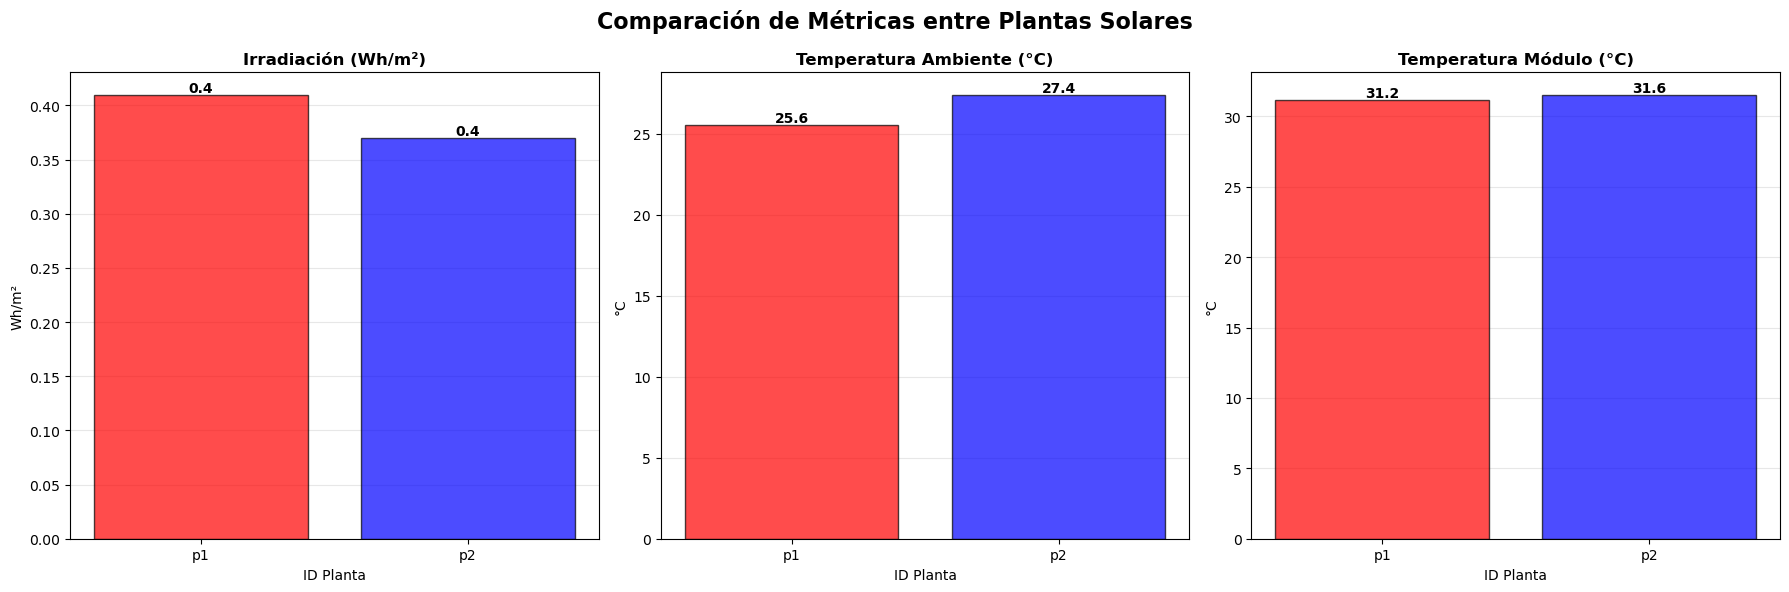

In [14]:
# Configurar el gráfico con subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparación de Métricas entre Plantas Solares', fontsize=16, fontweight='bold')

# Colores para cada planta con transparencia (alpha)
colores = ['red', 'blue']
alpha = 0.7  # Transparencia para tonos pastel

# Preparar datos para los gráficos
plantas = resultado_captacion.index
variables = ['irradiacion_wh_m2', 'temperatura_ambiente_c', 'temperatura_modulo_c']
titulos = ['Irradiación (Wh/m²)', 'Temperatura Ambiente (°C)', 'Temperatura Módulo (°C)']

# Crear cada subplot
for i, (var, titulo) in enumerate(zip(variables, titulos)):
    valores = resultado_captacion[var].values
    
    # Crear gráfico de barras
    bars = axes[i].bar(plantas, valores, color=colores, alpha=alpha, edgecolor='black', linewidth=1)
    
    # Configurar cada subplot
    axes[i].set_title(titulo, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('ID Planta', fontsize=10)
    axes[i].set_ylabel(titulo.split('(')[1].replace(')', ''), fontsize=10)
    
    # Añadir valores en las barras
    for j, bar in enumerate(bars):
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height,
                    f'{valores[j]:.1f}',
                    ha='center', va='bottom', fontweight='bold')
    
    # Mejorar apariencia
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].set_axisbelow(True)

# Ajustar layout
plt.tight_layout()
plt.show()

# Insight 4: No existen problemas en la captación

## Conclusiones Ejecutivas

Tras el análisis comparativo de las métricas de captación entre las plantas solares P1 y P2, **no se han identificado anomalías significativas que indiquen problemas en esta fase del proceso**.

### Hallazgos Clave:

- **Irradiación solar**: Ambas plantas presentan valores prácticamente idénticos (0.4 Wh/m² en promedio), confirmando condiciones de captación homogéneas
- **Temperatura ambiente**: Diferencia mínima entre plantas (P1: 25.6°C vs P2: 27.4°C), dentro de rangos normales de operación
- **Temperatura del módulo**: Valores muy similares (P1: 31.2°C vs P2: 31.6°C), indicando funcionamiento térmico adecuado

### Recomendación Estratégica:

**Los datos confirman que la fase de captación solar opera correctamente en ambas instalaciones.** Por tanto, los posibles factores que están afectando el rendimiento del sistema deben buscarse en **fases posteriores** del proceso de conversión energética (inversores, transformadores, distribución, etc.).



In [15]:
temp_corr = captacion[['id_planta','irradiacion_wh_m2','temperatura_ambiente_c','temperatura_modulo_c']].select_dtypes(include = 'number').corr()


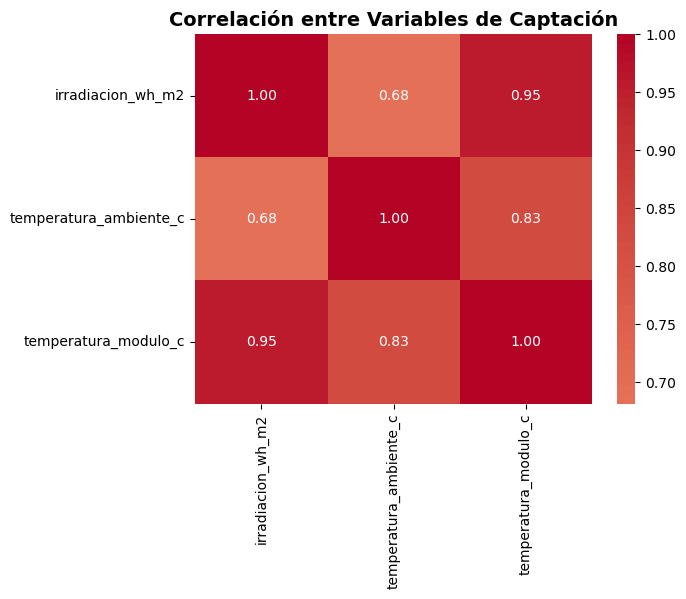

In [16]:
# heatmap de temp_corrplt.figure(figsize=(8, 6))
sns.heatmap(temp_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre Variables de Captación', fontsize=14, fontweight='bold')
plt.show()

In [17]:
temp_pair= captacion[['id_planta','irradiacion_wh_m2','temperatura_ambiente_c','temperatura_modulo_c']]

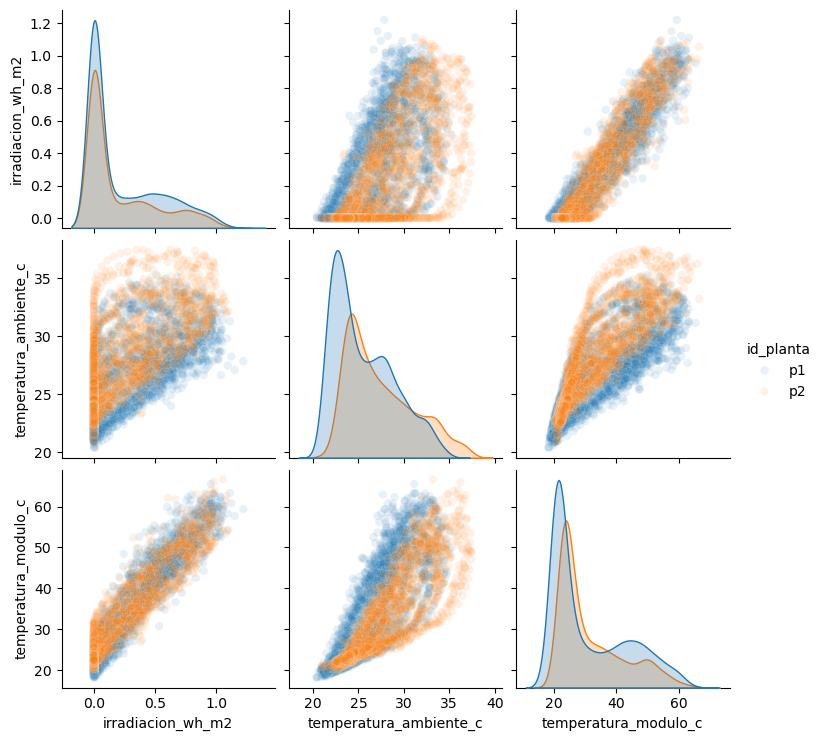

In [18]:
# crea un pairplot con alpha=0.1 para ver mejor el solape
sns.pairplot(temp_pair, hue='id_planta', diag_kind='kde', plot_kws={'alpha': 0.1})

In [19]:
captacion.head()

,id_planta,id_inversor,id_sensor_meteorologico,mes,dia,time,hora,minuto,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c
fecha_hora,,,,,,,,,,,
2020-05-15 00:00:00,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507
2020-05-15 00:15:00,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,00:15:00,0,15,0.0,25.084589,22.761668
2020-05-15 00:30:00,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,00:30:00,0,30,0.0,24.935753,22.592306
2020-05-15 00:45:00,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,00:45:00,0,45,0.0,24.846130,22.360852
2020-05-15 01:00:00,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,01:00:00,1,0,0.0,24.621525,22.165423


In [20]:
temp_hora_planta = pd.crosstab(captacion['hora'], captacion['id_planta'], values=captacion['irradiacion_wh_m2'], aggfunc='sum')

In [21]:
temp_hora_planta

id_planta,p1,p2
hora,,
0,0.000000,0.000102
1,0.000000,0.000106
2,0.000000,0.000115
3,0.000000,0.000344
4,0.000000,0.000526
5,0.014891,0.023962
6,5.244716,3.709666
7,25.753335,16.302686
8,50.683759,33.394774


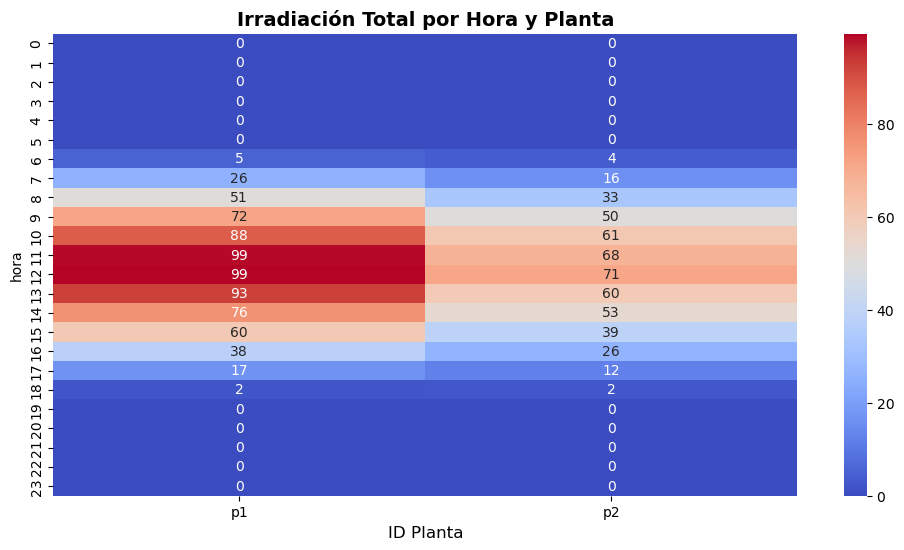

In [22]:
# heatmap sobre temp_hora_planta
plt.figure(figsize=(12, 6))
sns.heatmap(temp_hora_planta, cmap='coolwarm', annot=True, fmt='.0f')
plt.title('Irradiación Total por Hora y Planta', fontsize=14, fontweight='bold')
plt.xlabel('ID Planta', fontsize=12);

In [23]:
temp_hora_planta_temp = pd.crosstab(captacion['hora'], captacion['id_planta'], values=captacion['temperatura_ambiente_c'], aggfunc='mean')

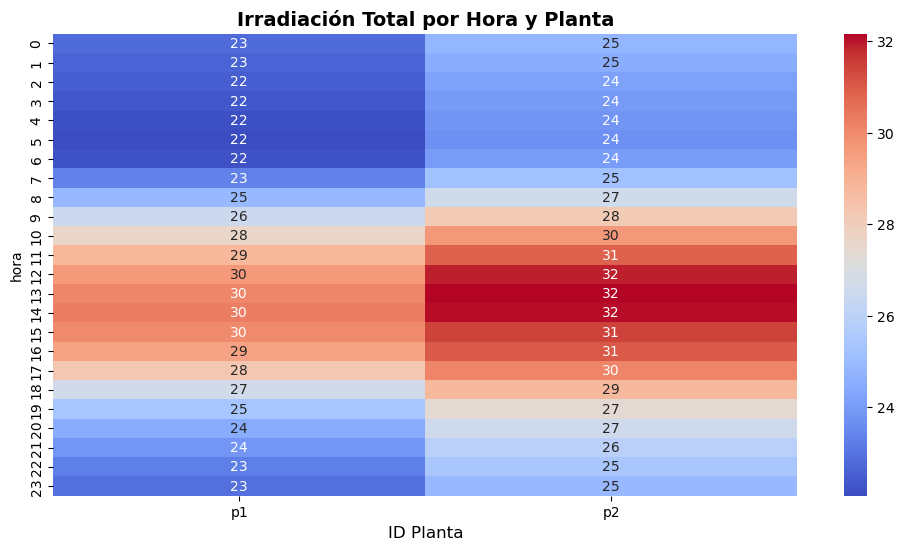

In [24]:
# heatmap sobre temp_hora_planta
plt.figure(figsize=(12, 6))
sns.heatmap(temp_hora_planta_temp, cmap='coolwarm', annot=True, fmt='.0f')
plt.title('Irradiación Total por Hora y Planta', fontsize=14, fontweight='bold')
plt.xlabel('ID Planta', fontsize=12);

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 136472 entries, 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id_planta                136472 non-null  object 
 1   id_inversor              136472 non-null  object 
 2   id_sensor_meteorologico  136472 non-null  object 
 3   mes                      136472 non-null  int32  
 4   dia                      136472 non-null  int32  
 5   time                     136472 non-null  object 
 6   hora                     136472 non-null  int32  
 7   minuto                   136472 non-null  int32  
 8   irradiacion_wh_m2        136472 non-null  float64
 9   temperatura_ambiente_c   136472 non-null  float64
 10  temperatura_modulo_c     136472 non-null  float64
 11  potencia_dc_kw           136472 non-null  float64
 12  eficiencia               136472 non-null  float64
 13  potencia_ac_kw           

In [28]:
df.loc[(df.index.date == pd.to_datetime('2020-05-15').date()) & (df['hora'] >= 10) & (df['hora'] <= 13)]


,id_planta,id_inversor,id_sensor_meteorologico,mes,dia,time,hora,minuto,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c,potencia_dc_kw,eficiencia,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
fecha_hora,,,,,,,,,,,,,,,,
2020-05-15 10:00:00,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,10:00:00,10,0,0.670675,28.632192,52.547736,600.837500,97.992386,588.775000,1161.250000,6.260720e+06
2020-05-15 10:00:00,p1,1IF53ai7Xc0U56Y,sensor_p1,5,15,10:00:00,10,0,0.670675,28.632192,52.547736,856.700000,97.723824,837.200000,1390.714286,6.185036e+06
2020-05-15 10:00:00,p1,3PZuoBAID5Wc2HD,sensor_p1,5,15,10:00:00,10,0,0.670675,28.632192,52.547736,738.462500,97.770706,722.000000,1366.375000,6.989125e+06
2020-05-15 10:00:00,p1,7JYdWkrLSPkdwr4,sensor_p1,5,15,10:00:00,10,0,0.670675,28.632192,52.547736,730.137500,97.827464,714.275000,1327.000000,7.604287e+06
2020-05-15 10:00:00,p1,McdE0feGgRqW7Ca,sensor_p1,5,15,10:00:00,10,0,0.670675,28.632192,52.547736,1000.542857,97.678403,977.314286,1405.571429,7.160370e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-05-15 13:45:00,p2,q49J1IKaHRwDQnt,sensor_p2,5,15,13:45:00,13,45,0.866027,36.614378,52.980611,1135.226667,97.592258,1107.893333,6557.800000,3.464808e+05
2020-05-15 13:45:00,p2,rrq4fwE8jgrTyWY,sensor_p2,5,15,13:45:00,13,45,0.866027,36.614378,52.980611,1164.773333,97.581790,1136.606667,2962.333333,1.209671e+08
2020-05-15 13:45:00,p2,vOuJvMaM2sgwLmb,sensor_p2,5,15,13:45:00,13,45,0.866027,36.614378,52.980611,1219.235714,97.500776,1188.764286,6896.285714,2.218858e+06


In [31]:
# Correlación entre irradiacion_wh_m2 y potencia_dc_kw
df['irradiacion_wh_m2'].corr(df['potencia_dc_kw'])

np.float64(0.8848926823751961)

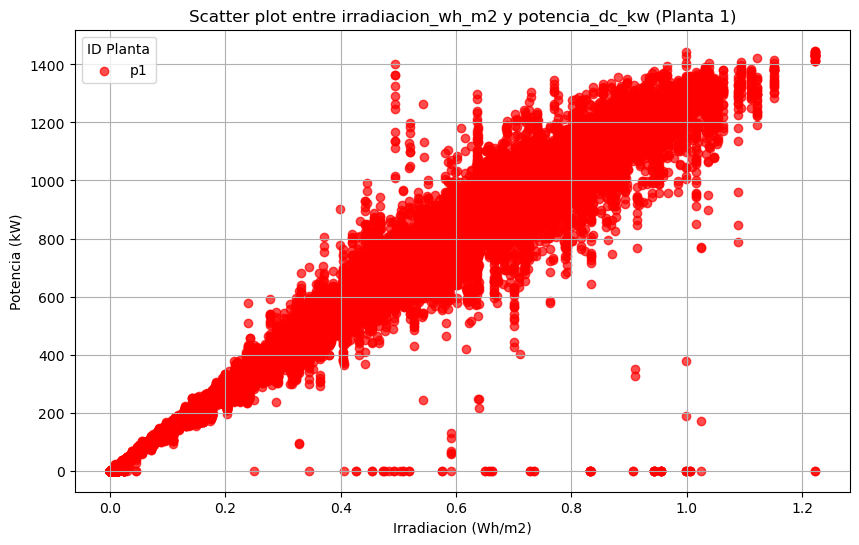

In [34]:
# scatter plot entre irradiacion_wh_m2 y potencia_dc_kw solo para la planta 1
plt.figure(figsize=(10, 6))
planta = 'p1'
mask = df['id_planta'] == planta
plt.scatter(df.loc[mask, 'irradiacion_wh_m2'], df.loc[mask, 'potencia_dc_kw'], 
            alpha=alpha, label=planta, color=colores[0])
plt.title('Scatter plot entre irradiacion_wh_m2 y potencia_dc_kw (Planta 1)')
plt.xlabel('Irradiacion (Wh/m2)')
plt.ylabel('Potencia (kW)')
plt.legend(title='ID Planta')
plt.grid()
plt.show()

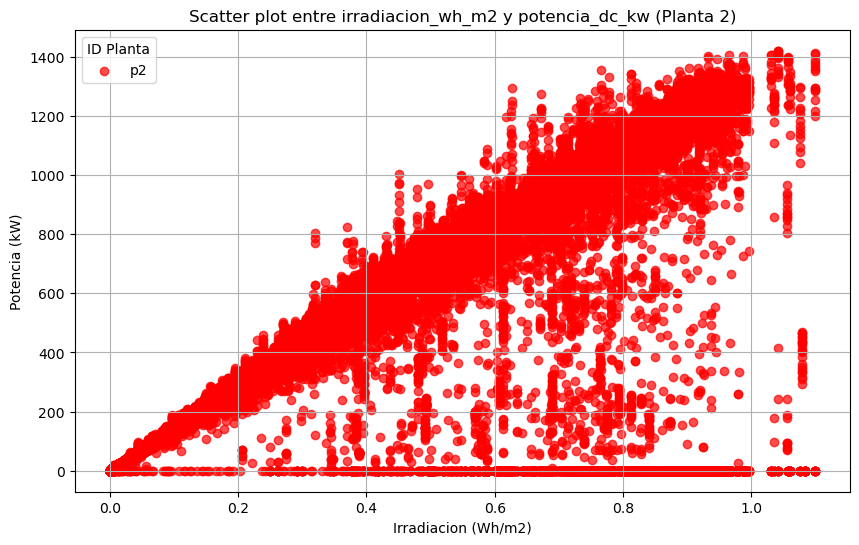

In [35]:
# scatter plot entre irradiacion_wh_m2 y potencia_dc_kw solo para la planta 2
plt.figure(figsize=(10, 6))
planta = 'p2'
mask = df['id_planta'] == planta
plt.scatter(df.loc[mask, 'irradiacion_wh_m2'], df.loc[mask, 'potencia_dc_kw'], 
            alpha=alpha, label=planta, color=colores[0])
plt.title('Scatter plot entre irradiacion_wh_m2 y potencia_dc_kw (Planta 2)')
plt.xlabel('Irradiacion (Wh/m2)')
plt.ylabel('Potencia (kW)')
plt.legend(title='ID Planta')
plt.grid()
plt.show()

In [36]:
# Parámetros
irradiacion_umbral = 0.3     # Wh/m² — irradiancia moderada
potencia_umbral_kw = 50      # Potencia baja (ajústalo si conoces Pn de inversores)

# Filtro de eventos sospechosos en planta p2
sospechosos_p2 = df[
    (df["id_planta"] == "p2") &
    (df["irradiacion_wh_m2"] > irradiacion_umbral) &
    (df["potencia_dc_kw"] <= potencia_umbral_kw)
].copy()

sospechosos_p2

,id_planta,id_inversor,id_sensor_meteorologico,mes,dia,time,hora,minuto,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c,potencia_dc_kw,eficiencia,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
fecha_hora,,,,,,,,,,,,,,,,
2020-05-15 09:45:00,p2,81aHJ1q11NBPMrL,sensor_p2,5,15,09:45:00,9,45,0.799746,31.375120,45.719524,0.0,100.0,0.0,1645.0,1.215280e+09
2020-05-15 09:45:00,p2,Et9kgGMDl729KT4,sensor_p2,5,15,09:45:00,9,45,0.799746,31.375120,45.719524,0.0,100.0,0.0,1541.0,1.705791e+06
2020-05-15 09:45:00,p2,Quc1TzYxW2pYoWX,sensor_p2,5,15,09:45:00,9,45,0.799746,31.375120,45.719524,0.0,100.0,0.0,1324.0,3.295104e+08
2020-05-15 09:45:00,p2,xoJJ8DcxJEcupym,sensor_p2,5,15,09:45:00,9,45,0.799746,31.375120,45.719524,0.0,100.0,0.0,1735.0,2.091453e+08
2020-05-15 10:00:00,p2,81aHJ1q11NBPMrL,sensor_p2,5,15,10:00:00,10,0,0.828096,31.892094,46.131174,0.0,100.0,0.0,1645.0,1.215280e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-16 14:30:00,p2,q49J1IKaHRwDQnt,sensor_p2,6,16,14:30:00,14,30,0.562944,30.833513,44.376507,0.0,100.0,0.0,0.0,3.437933e+04
2020-06-16 14:30:00,p2,rrq4fwE8jgrTyWY,sensor_p2,6,16,14:30:00,14,30,0.562944,30.833513,44.376507,0.0,100.0,0.0,0.0,8.075096e+06
2020-06-16 14:30:00,p2,vOuJvMaM2sgwLmb,sensor_p2,6,16,14:30:00,14,30,0.562944,30.833513,44.376507,0.0,100.0,0.0,0.0,1.730228e+05


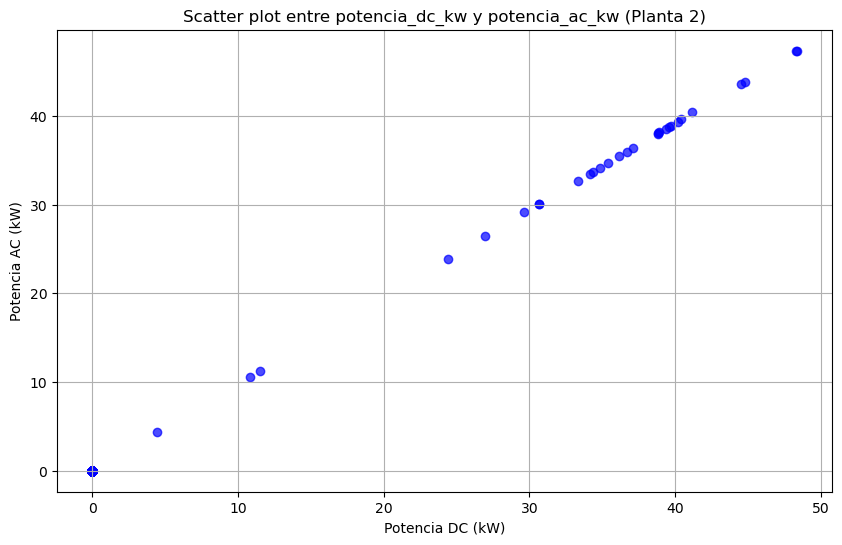

In [37]:
# sobre sospechosos_p2 hacer un scatter plot entre potencia_dc_kw y potencia_ac_kw
plt.figure(figsize=(10, 6))
plt.scatter(sospechosos_p2['potencia_dc_kw'], sospechosos_p2['potencia_ac_kw'], alpha=alpha, color=colores[1])
plt.title('Scatter plot entre potencia_dc_kw y potencia_ac_kw (Planta 2)')
plt.xlabel('Potencia DC (kW)')
plt.ylabel('Potencia AC (kW)')
plt.grid()
plt.show()

## Insight 5: Episodios de indisponibilidad operativa en planta P2
### Conclusiones Ejecutivas

El análisis cruzado entre la irradiación solar y la potencia generada (DC y AC) en la planta P2 revela la presencia de episodios de parada total o parcial de generación eléctrica, coincidentes con condiciones de irradiación media o alta.
Estos eventos no se deben a errores de medición, sino a indisponibilidades reales del sistema fotovoltaico o del inversor.

### Hallazgos Clave:

Correlación irradiación–potencia: En P2 se identifican múltiples intervalos con irradiación >0.3 Wh/m² y potencia DC ≈ 0 kW, un comportamiento no observado en P1.

Coherencia DC–AC: En los registros afectados, tanto la potencia DC como la AC caen simultáneamente, descartando fallos de sensorización o transmisión de datos.

Indicativo de parada real: El patrón sugiere desconexiones temporales de inversores, protecciones activadas o curtailments programados, más que un problema meteorológico.

Impacto potencial: Estos episodios reducen la disponibilidad técnica (AT) y podrían estar afectando el Performance Ratio (PR) y la energía neta entregada de la planta.

In [43]:
df.head()

,id_planta,id_inversor,id_sensor_meteorologico,mes,dia,time,hora,minuto,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c,potencia_dc_kw,eficiencia,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh,fecha,fecha_con_hora
fecha_hora,,,,,,,,,,,,,,,,,,
2020-05-15,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,6259559.0,2020-05-15,2020-05-15-0
2020-05-15,p1,1IF53ai7Xc0U56Y,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,6183645.0,2020-05-15,2020-05-15-0
2020-05-15,p1,3PZuoBAID5Wc2HD,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,6987759.0,2020-05-15,2020-05-15-0
2020-05-15,p1,7JYdWkrLSPkdwr4,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,7602960.0,2020-05-15,2020-05-15-0
2020-05-15,p1,McdE0feGgRqW7Ca,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,7158964.0,2020-05-15,2020-05-15-0


In [39]:
# crea una variable que sea solo la fecha a partir del indice
df['fecha'] = df.index.date

In [42]:
# crea una variable llamada fecha_con_hora que concatene la varialbe fecha y la variable hora separados por un guion medio
df['fecha_con_hora'] = df['fecha'].astype(str) + '-' + df['hora'].astype(str)

In [44]:
# crea un nuevo dataframe agregando por planta, fecha y hora y haciendo la media de potencia_dc_kw y de potencia_ac_kw
df_analisis_horario = df.groupby(['id_planta', 'fecha', 'hora']).agg({
    'potencia_dc_kw': 'mean',
    'potencia_ac_kw': 'mean'
}).reset_index()

In [45]:
df_analisis_horario

,id_planta,fecha,hora,potencia_dc_kw,potencia_ac_kw
0,p1,2020-05-15,0,0.0,0.0
1,p1,2020-05-15,1,0.0,0.0
2,p1,2020-05-15,2,0.0,0.0
3,p1,2020-05-15,3,0.0,0.0
4,p1,2020-05-15,4,0.0,0.0
...,...,...,...,...,...
1607,p2,2020-06-17,19,0.0,0.0
1608,p2,2020-06-17,20,0.0,0.0
1609,p2,2020-06-17,21,0.0,0.0
1610,p2,2020-06-17,22,0.0,0.0


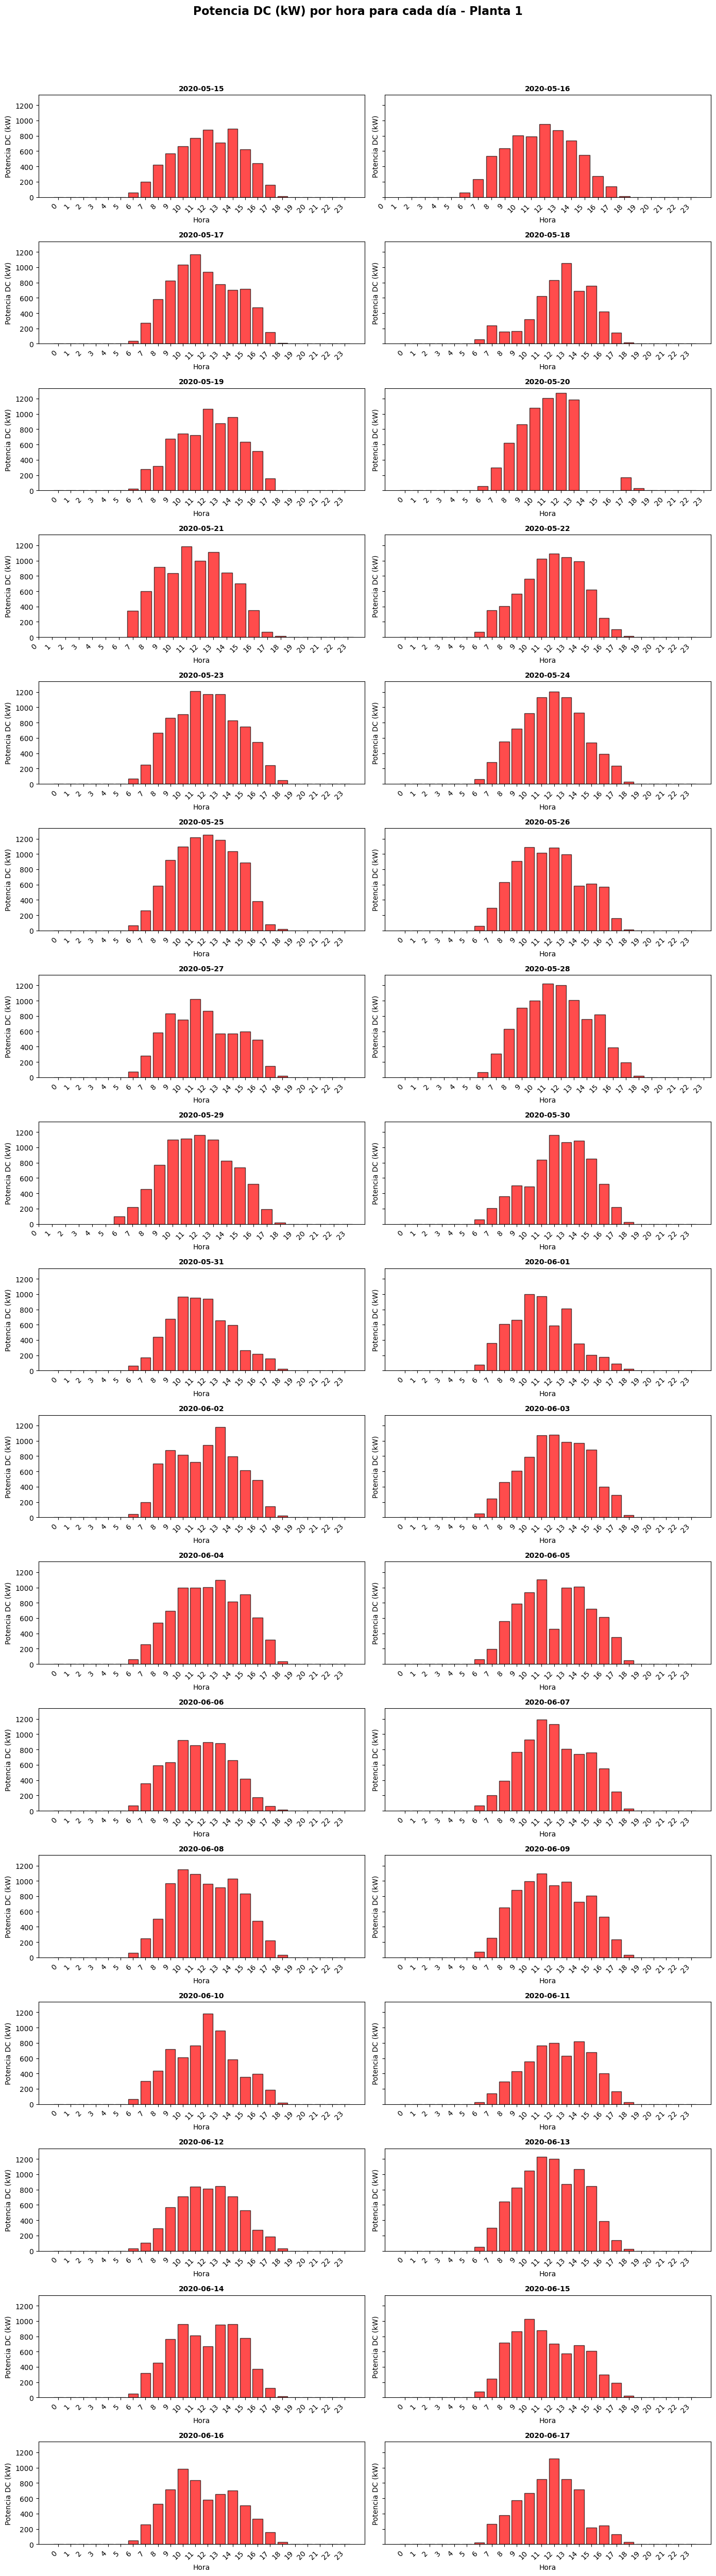

In [49]:
# Filtrar solo planta 1
df_p1 = df_analisis_horario[df_analisis_horario['id_planta'] == 'p1']

# Pivotar para tener fechas como columnas y horas como índice
pivot = df_p1.pivot(index='hora', columns='fecha', values='potencia_dc_kw')

# Crear gráfico de barras con subplots, dos columnas
n = len(pivot.columns)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), sharex=False, sharey=True)
axes = axes.flatten()

for i, fecha in enumerate(pivot.columns):
    axes[i].bar(pivot.index, pivot[fecha], color=colores[0], alpha=alpha, edgecolor='black')
    axes[i].set_title(str(fecha), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Hora')
    axes[i].set_ylabel('Potencia DC (kW)')
    axes[i].set_xticks(pivot.index)
    axes[i].set_xticklabels(pivot.index, rotation=45, ha='right')

# Eliminar subplots vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Potencia DC (kW) por hora para cada día - Planta 1', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

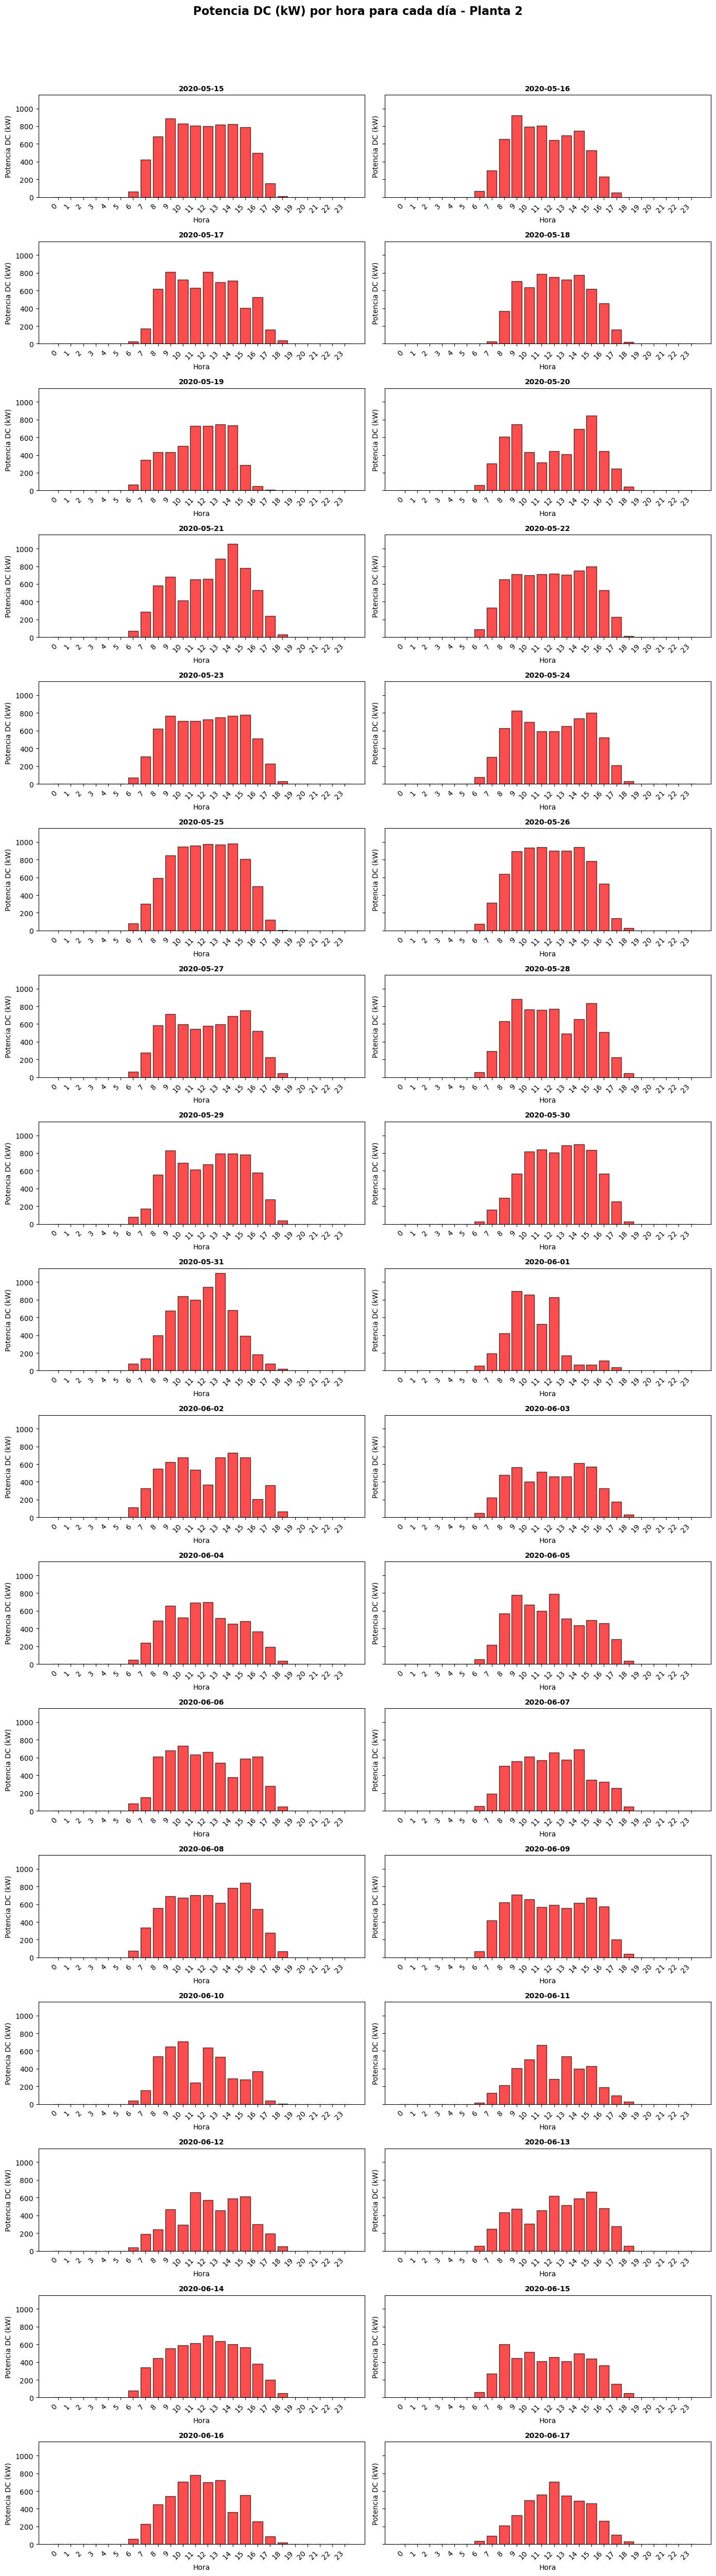

In [51]:
# Filtrar solo planta 2
df_p2 = df_analisis_horario[df_analisis_horario['id_planta'] == 'p2']

# Pivotar para tener fechas como columnas y horas como índice
pivot = df_p2.pivot(index='hora', columns='fecha', values='potencia_dc_kw')

# Crear gráfico de barras con subplots, dos columnas
n = len(pivot.columns)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), sharex=False, sharey=True)
axes = axes.flatten()

for i, fecha in enumerate(pivot.columns):
    axes[i].bar(pivot.index, pivot[fecha], color=colores[0], alpha=alpha, edgecolor='black')
    axes[i].set_title(str(fecha), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Hora')
    axes[i].set_ylabel('Potencia DC (kW)')
    axes[i].set_xticks(pivot.index)
    axes[i].set_xticklabels(pivot.index, rotation=45, ha='right')

# Eliminar subplots vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Potencia DC (kW) por hora para cada día - Planta 2', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [70]:
# Filtra directamente df para obtener solo los registros de las combinaciones de planta y día indicadas
fechas_p1 = pd.to_datetime(['2020-05-20', '2020-06-05', '2020-06-14']).date
fechas_p2 = pd.to_datetime(['2020-05-20', '2020-05-24', '2020-06-01', '2020-06-10']).date
df_problemas = df.loc[
    ((df['id_planta'] == 'p1') & (df['fecha'].isin(fechas_p1))) |
    ((df['id_planta'] == 'p2') & (df['fecha'].isin(fechas_p2)))
].copy()

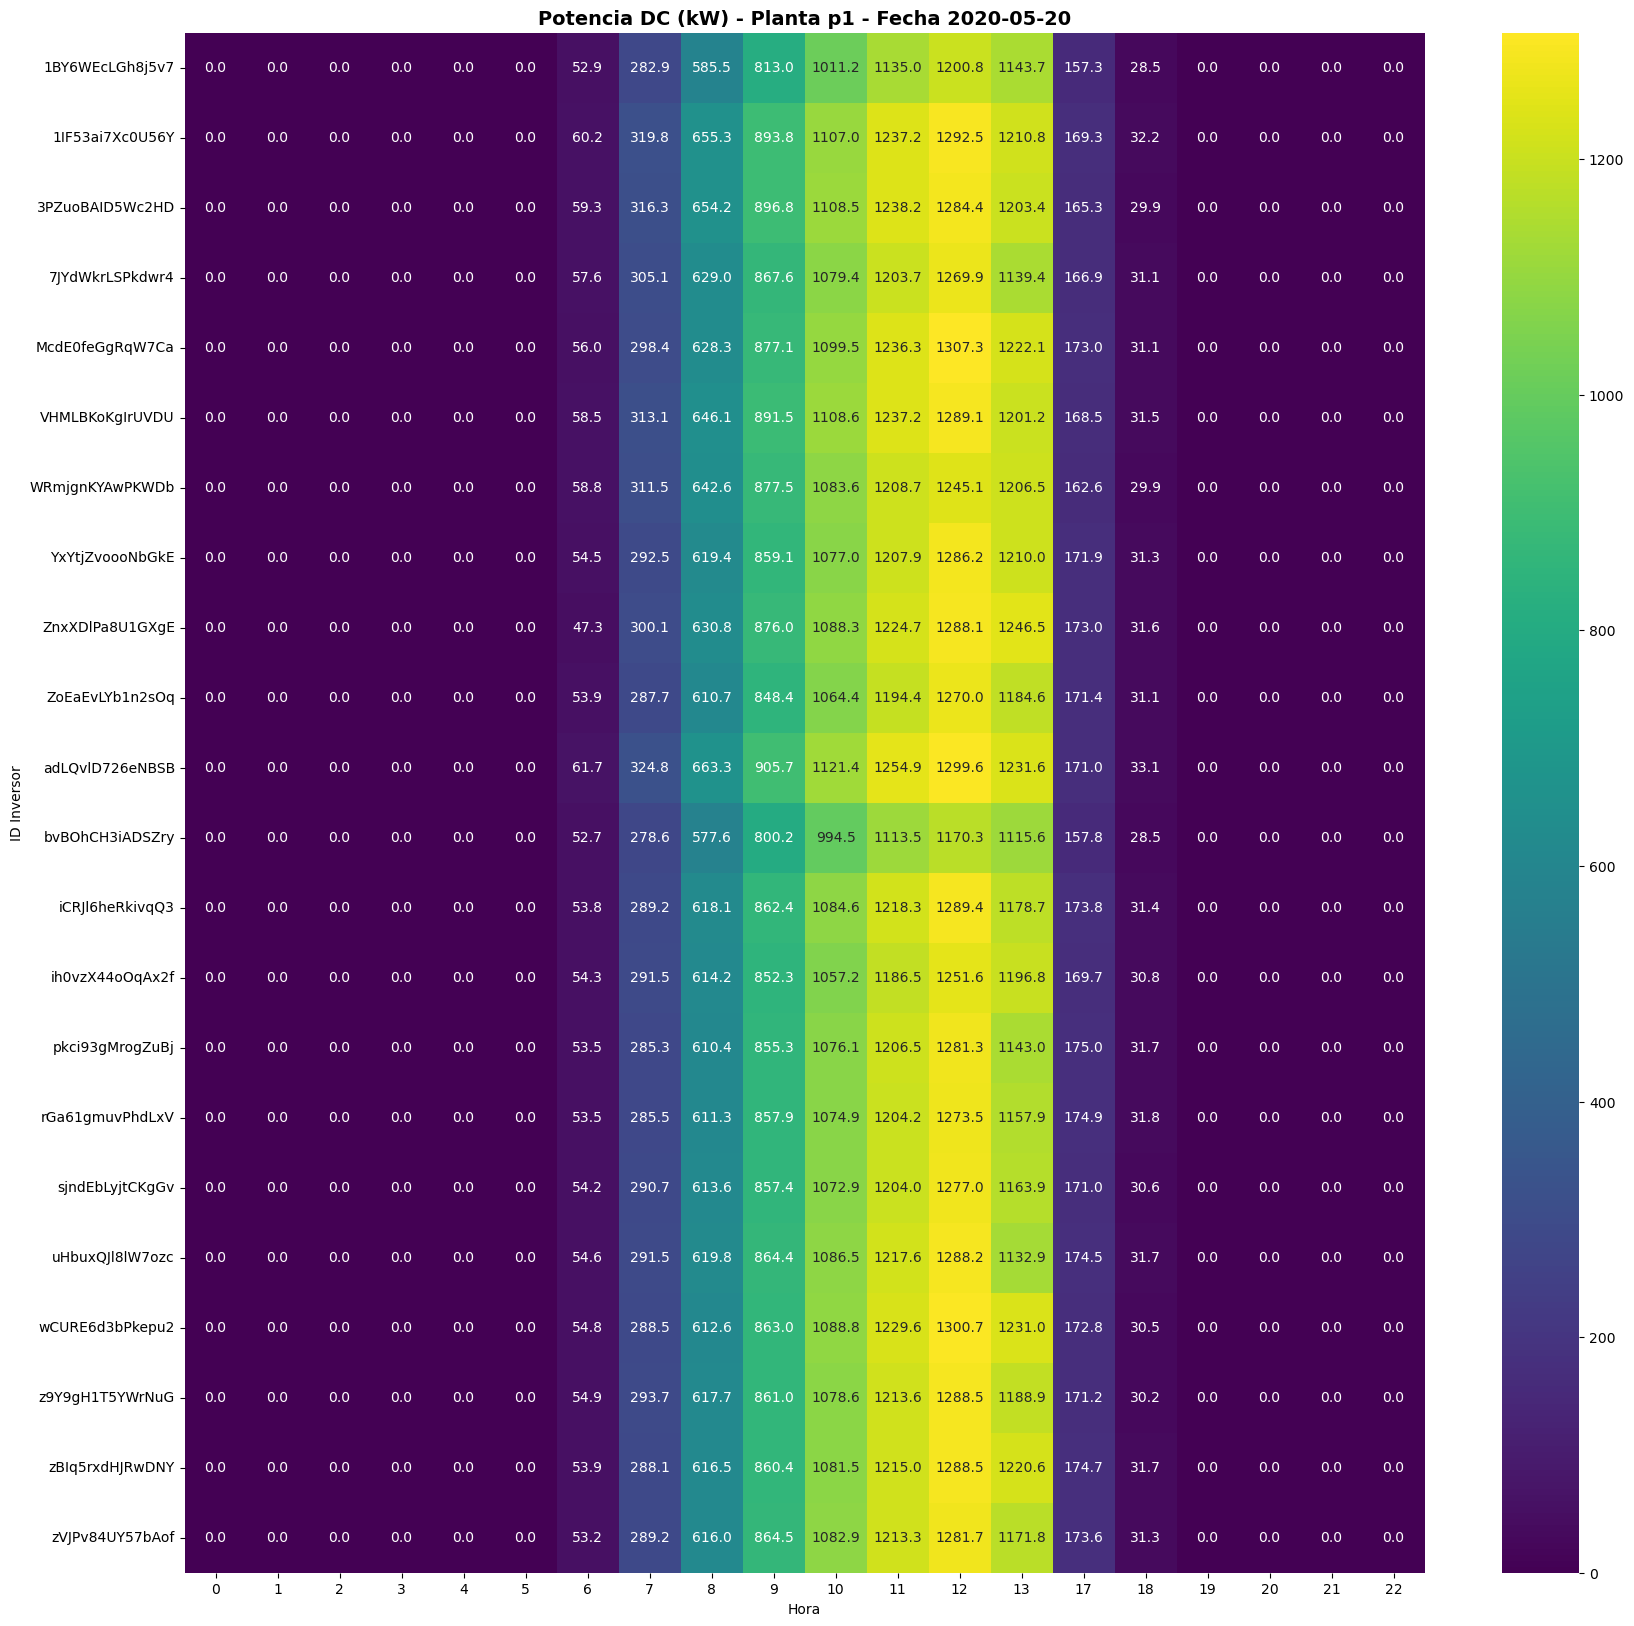

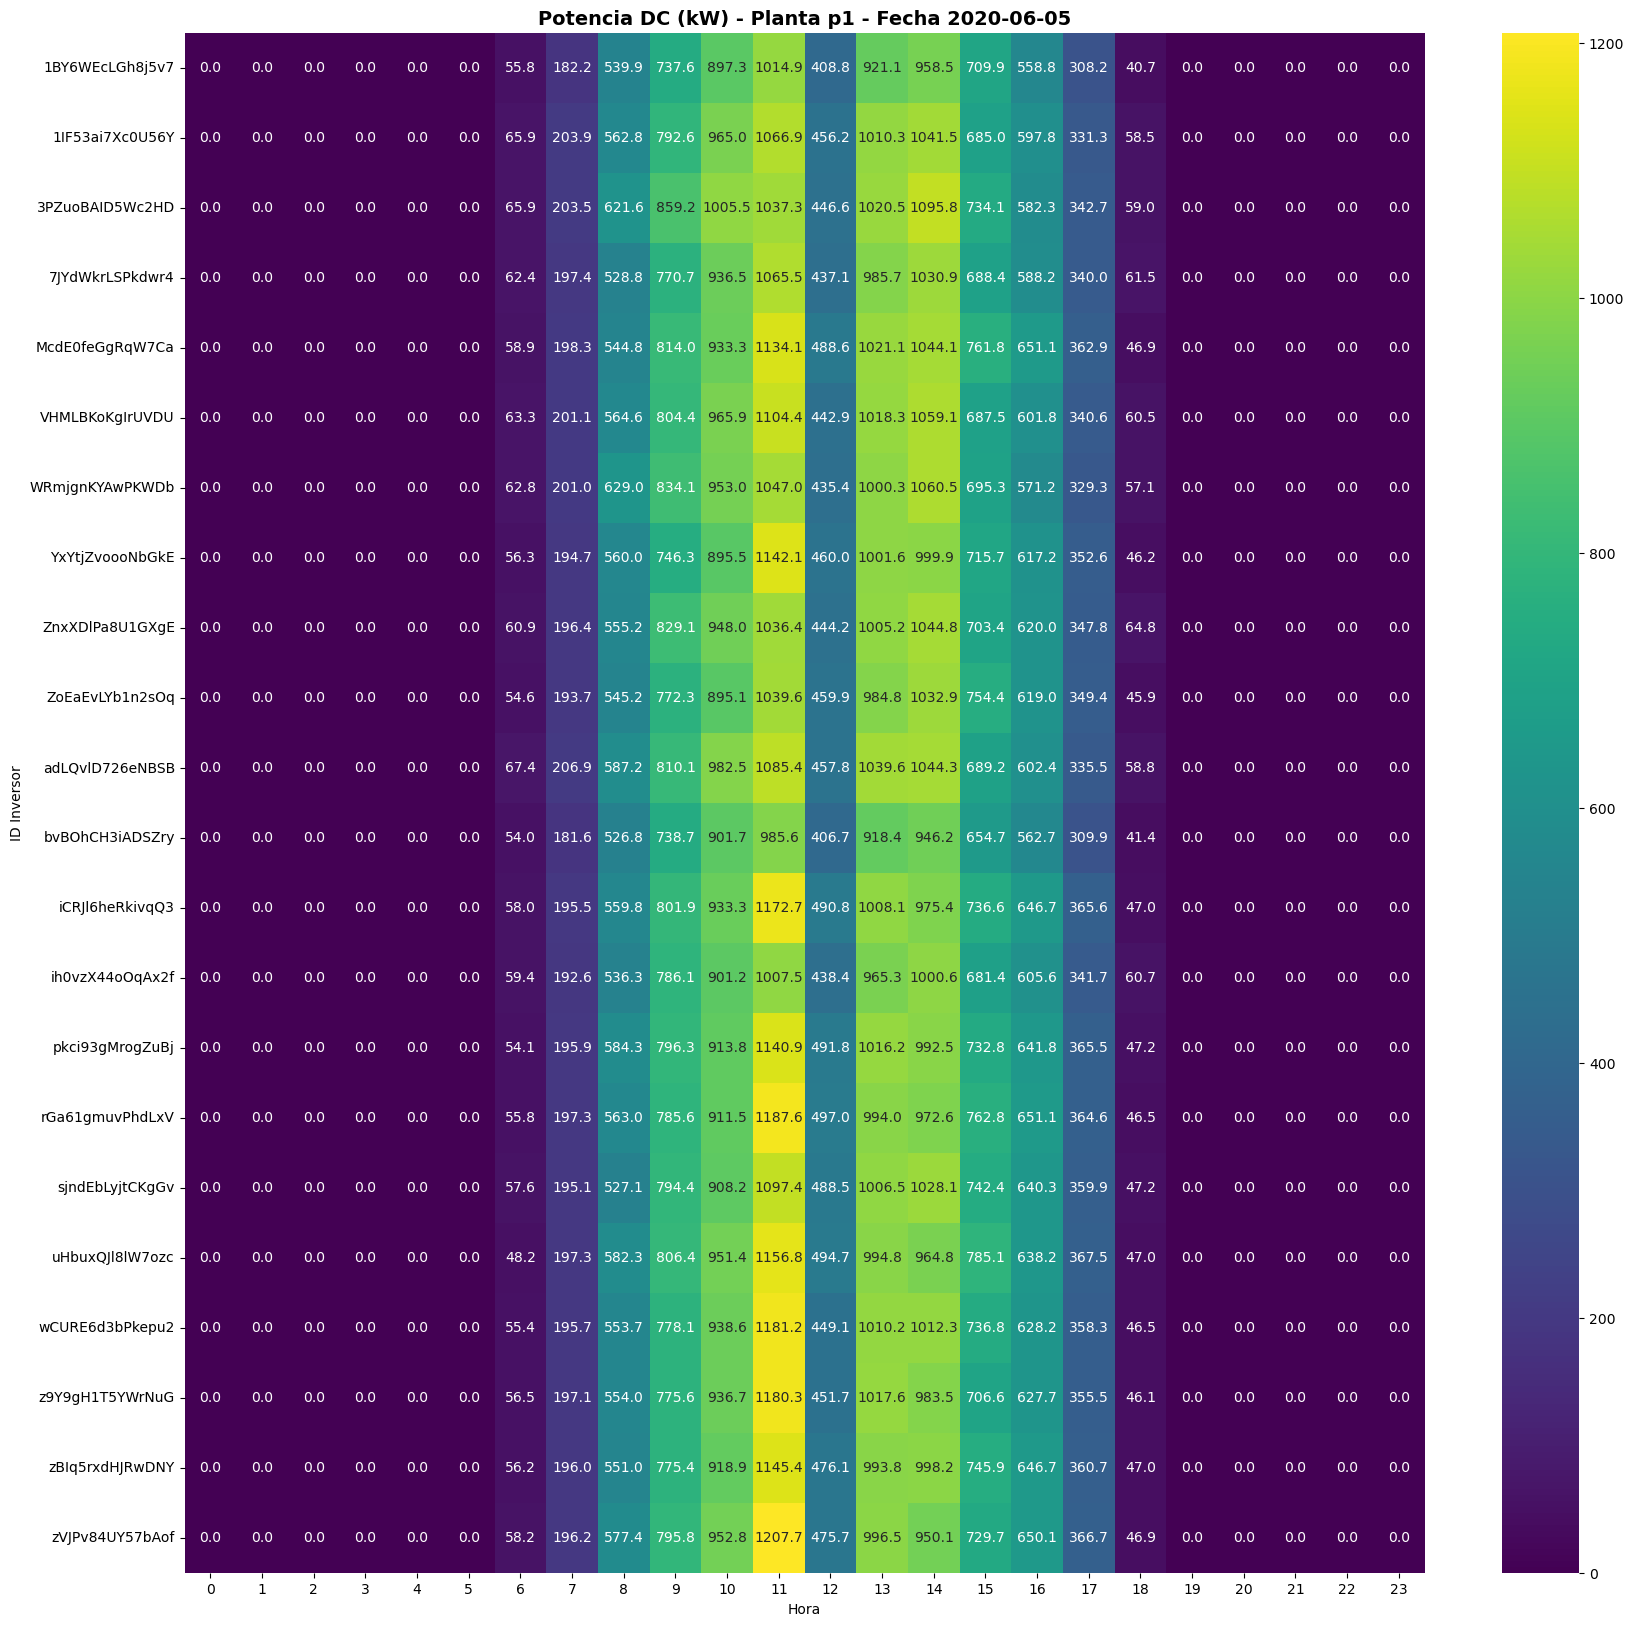

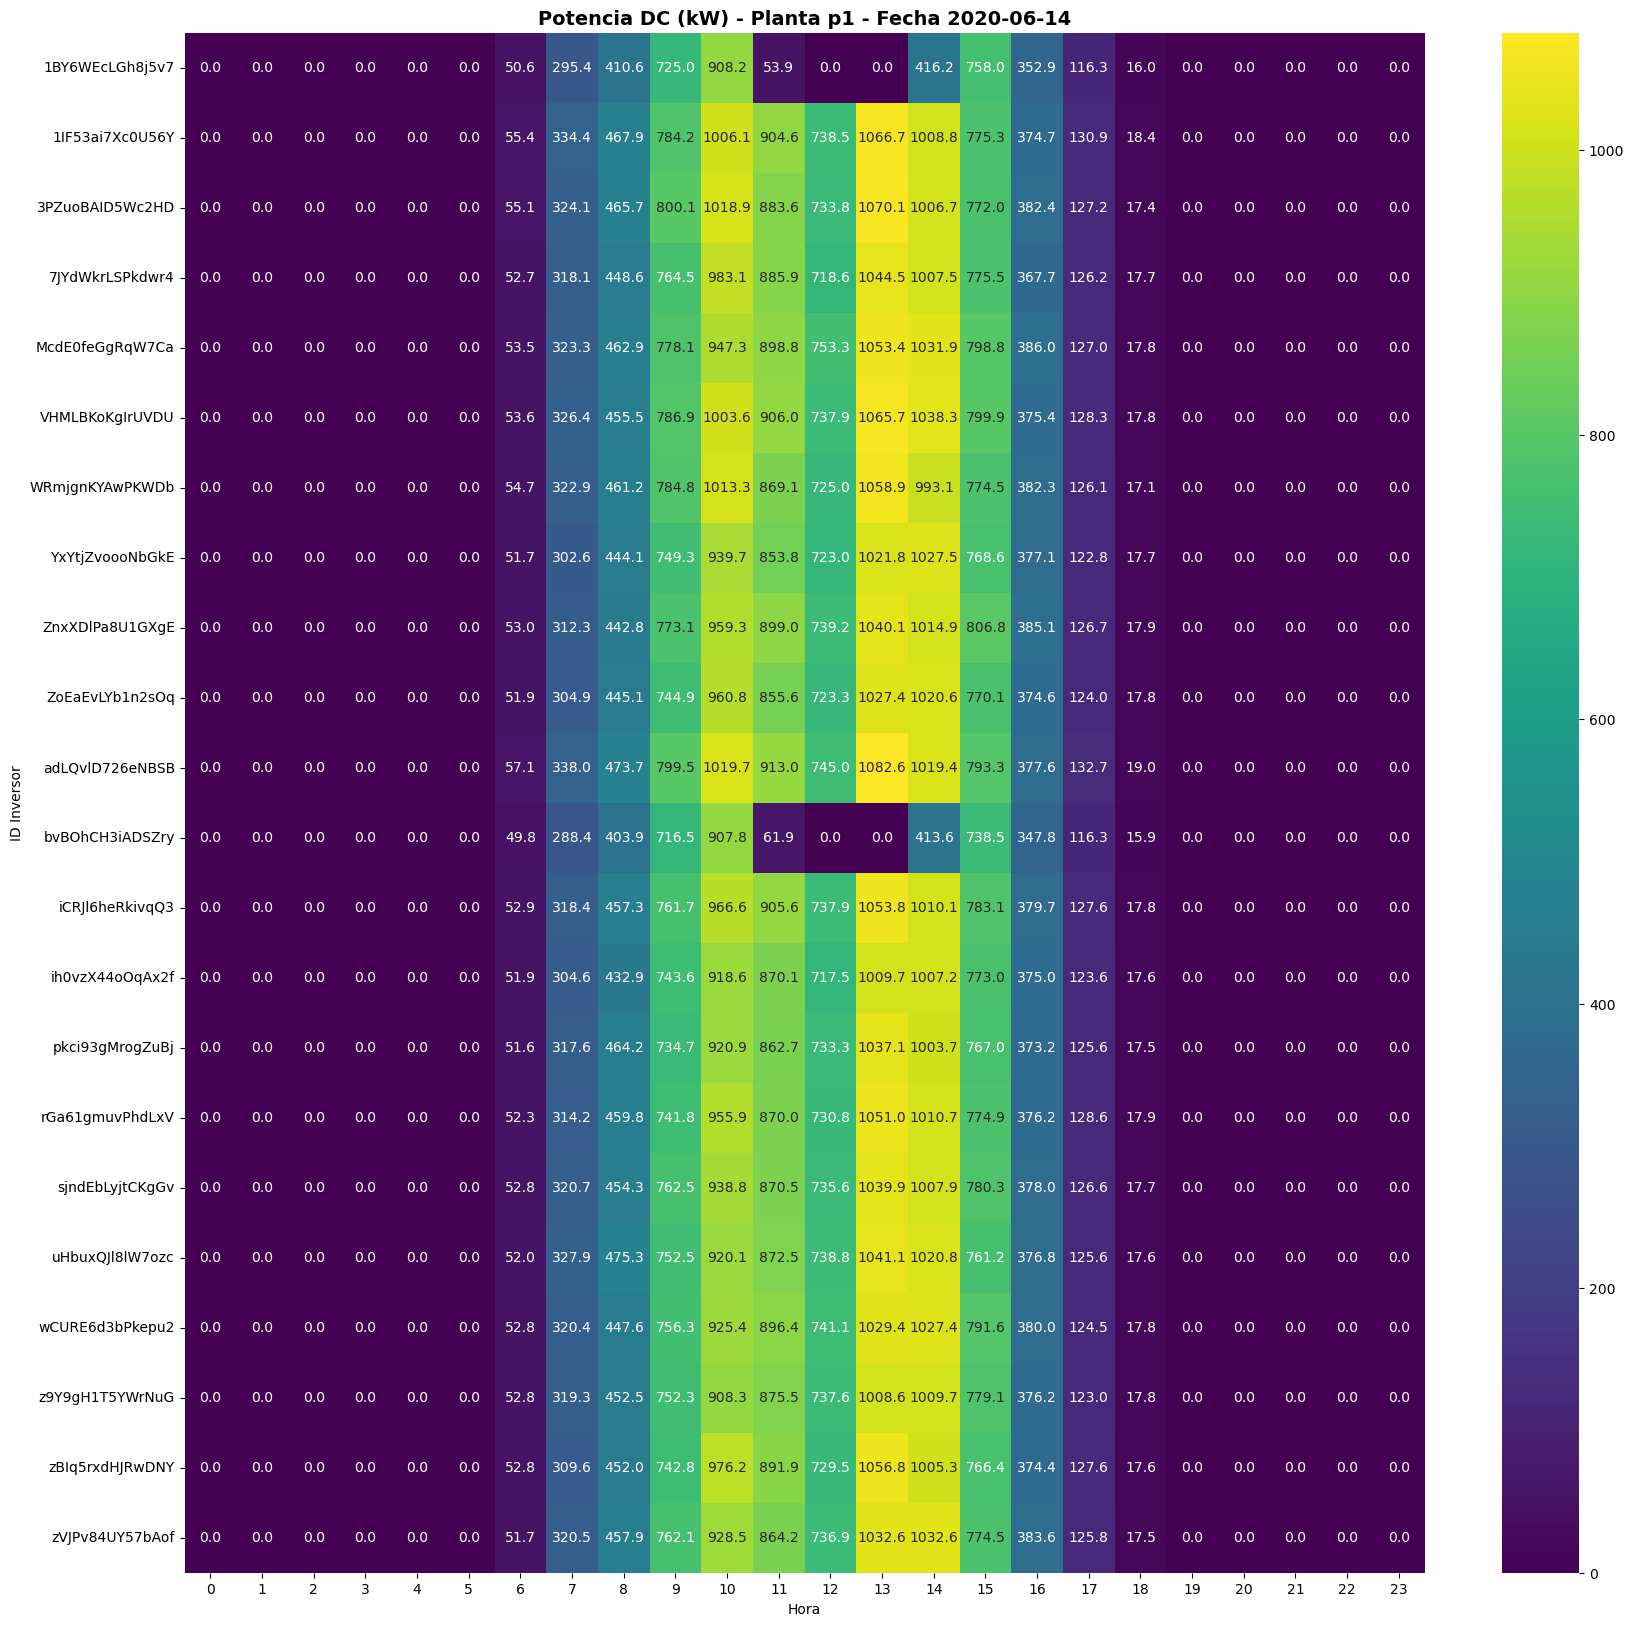

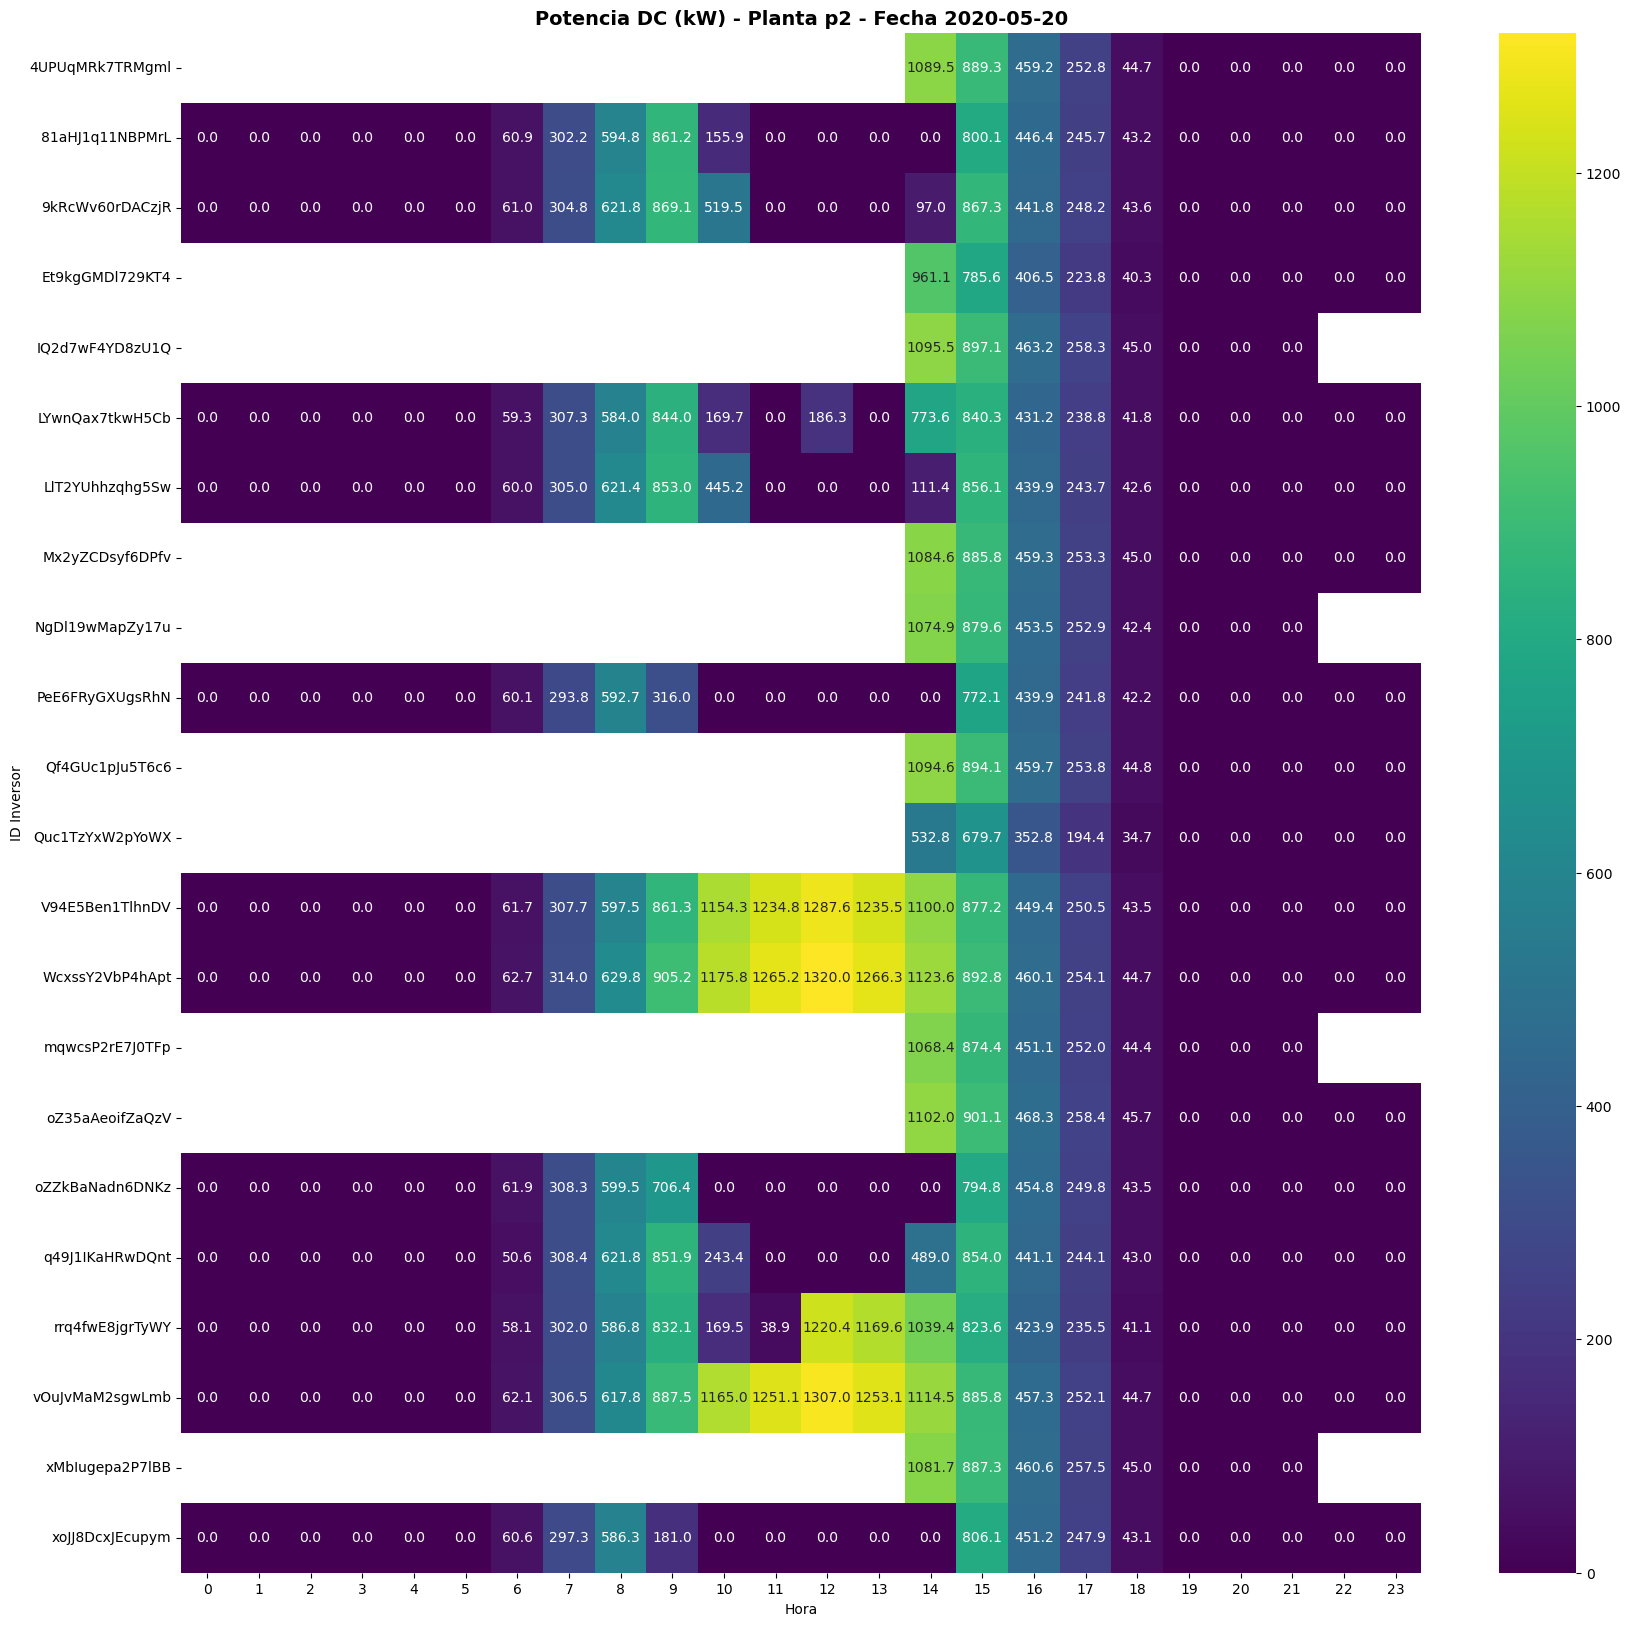

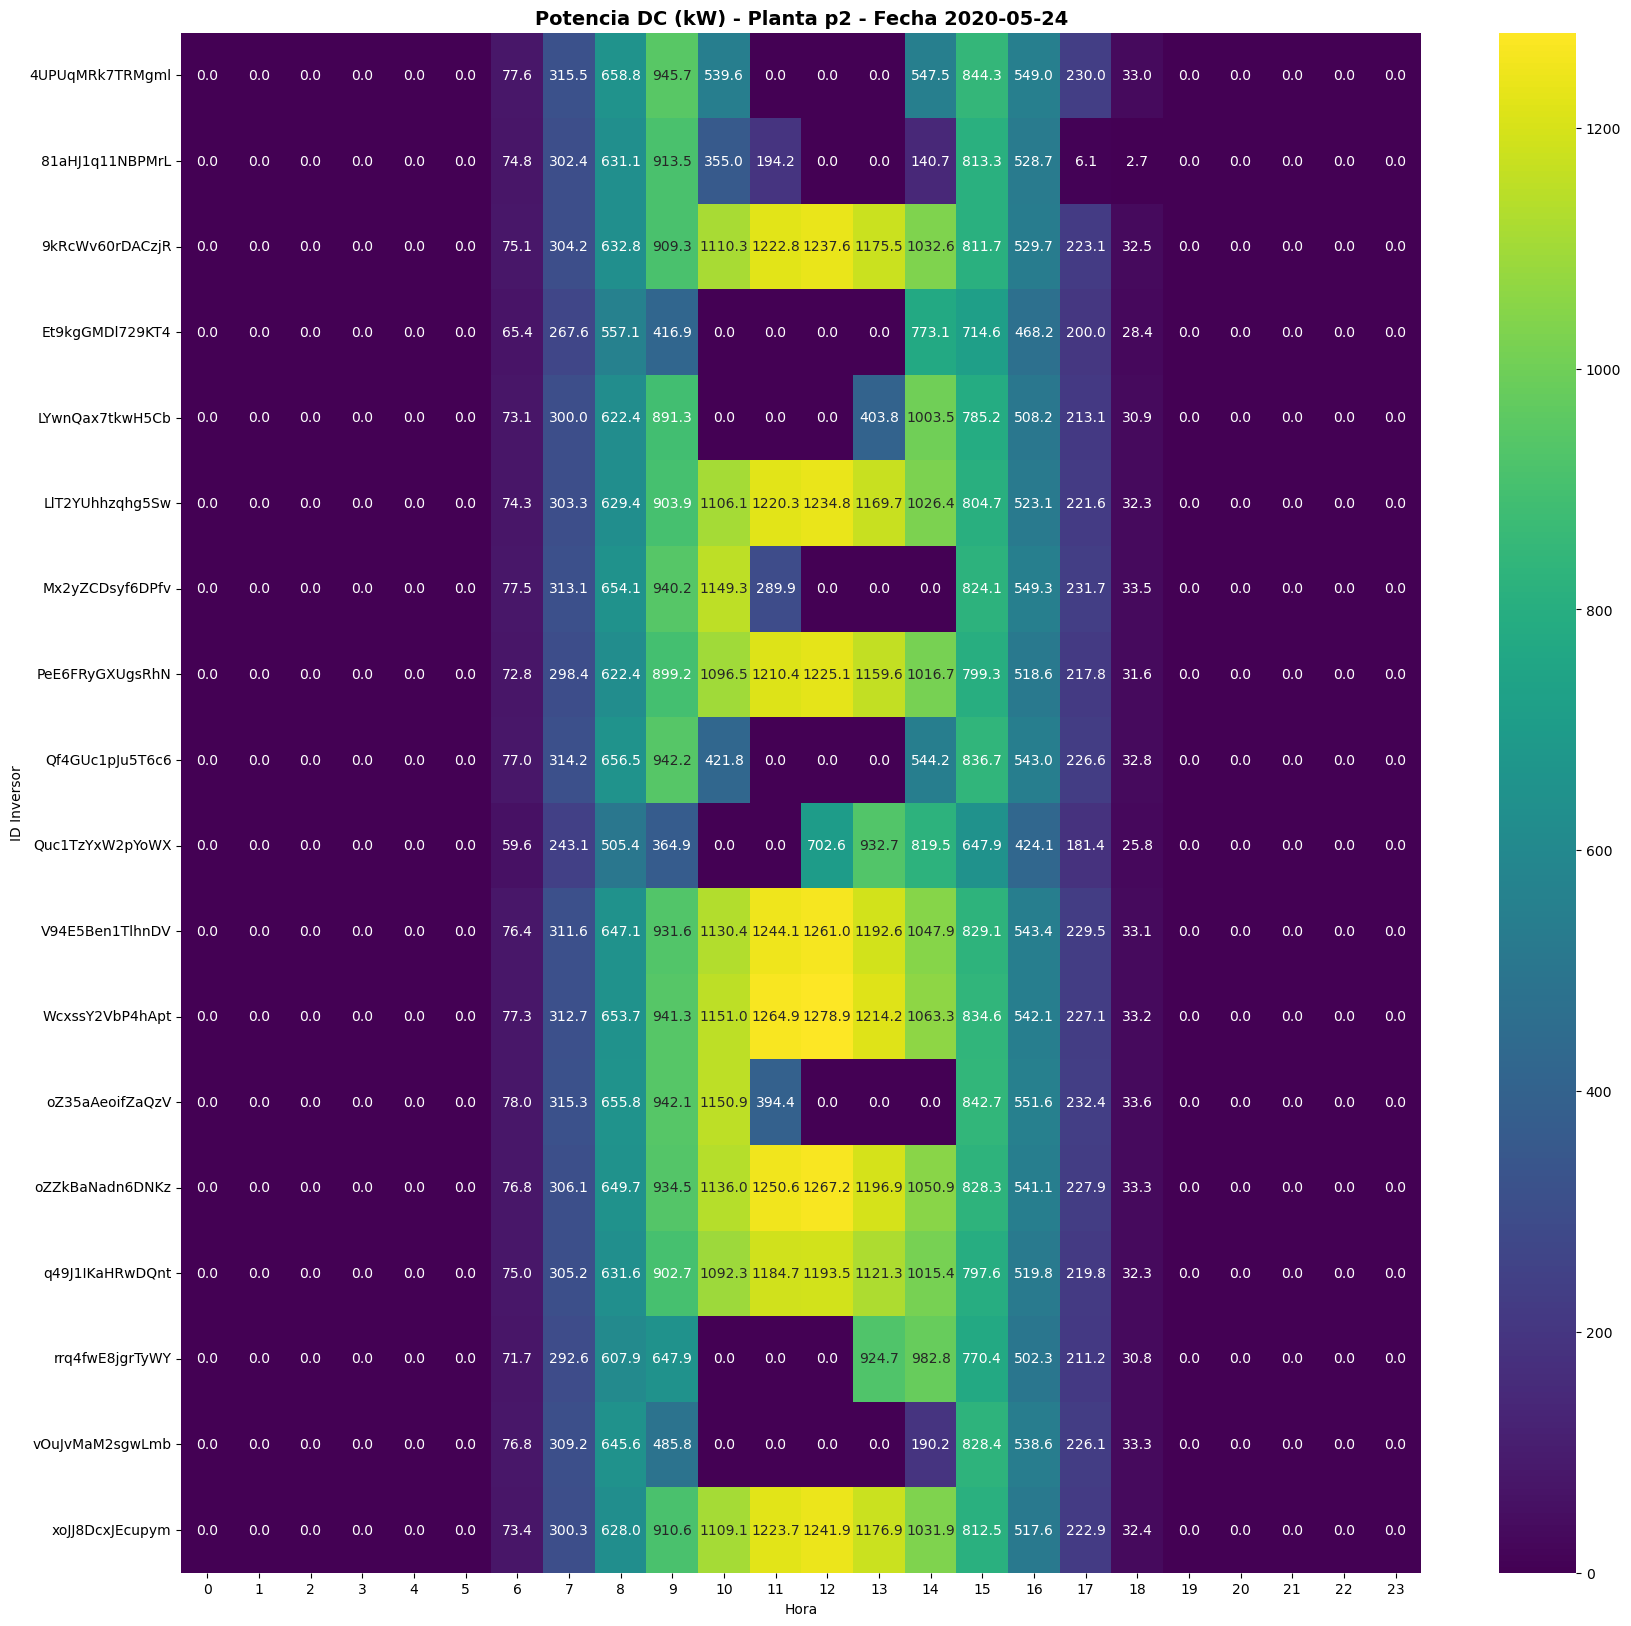

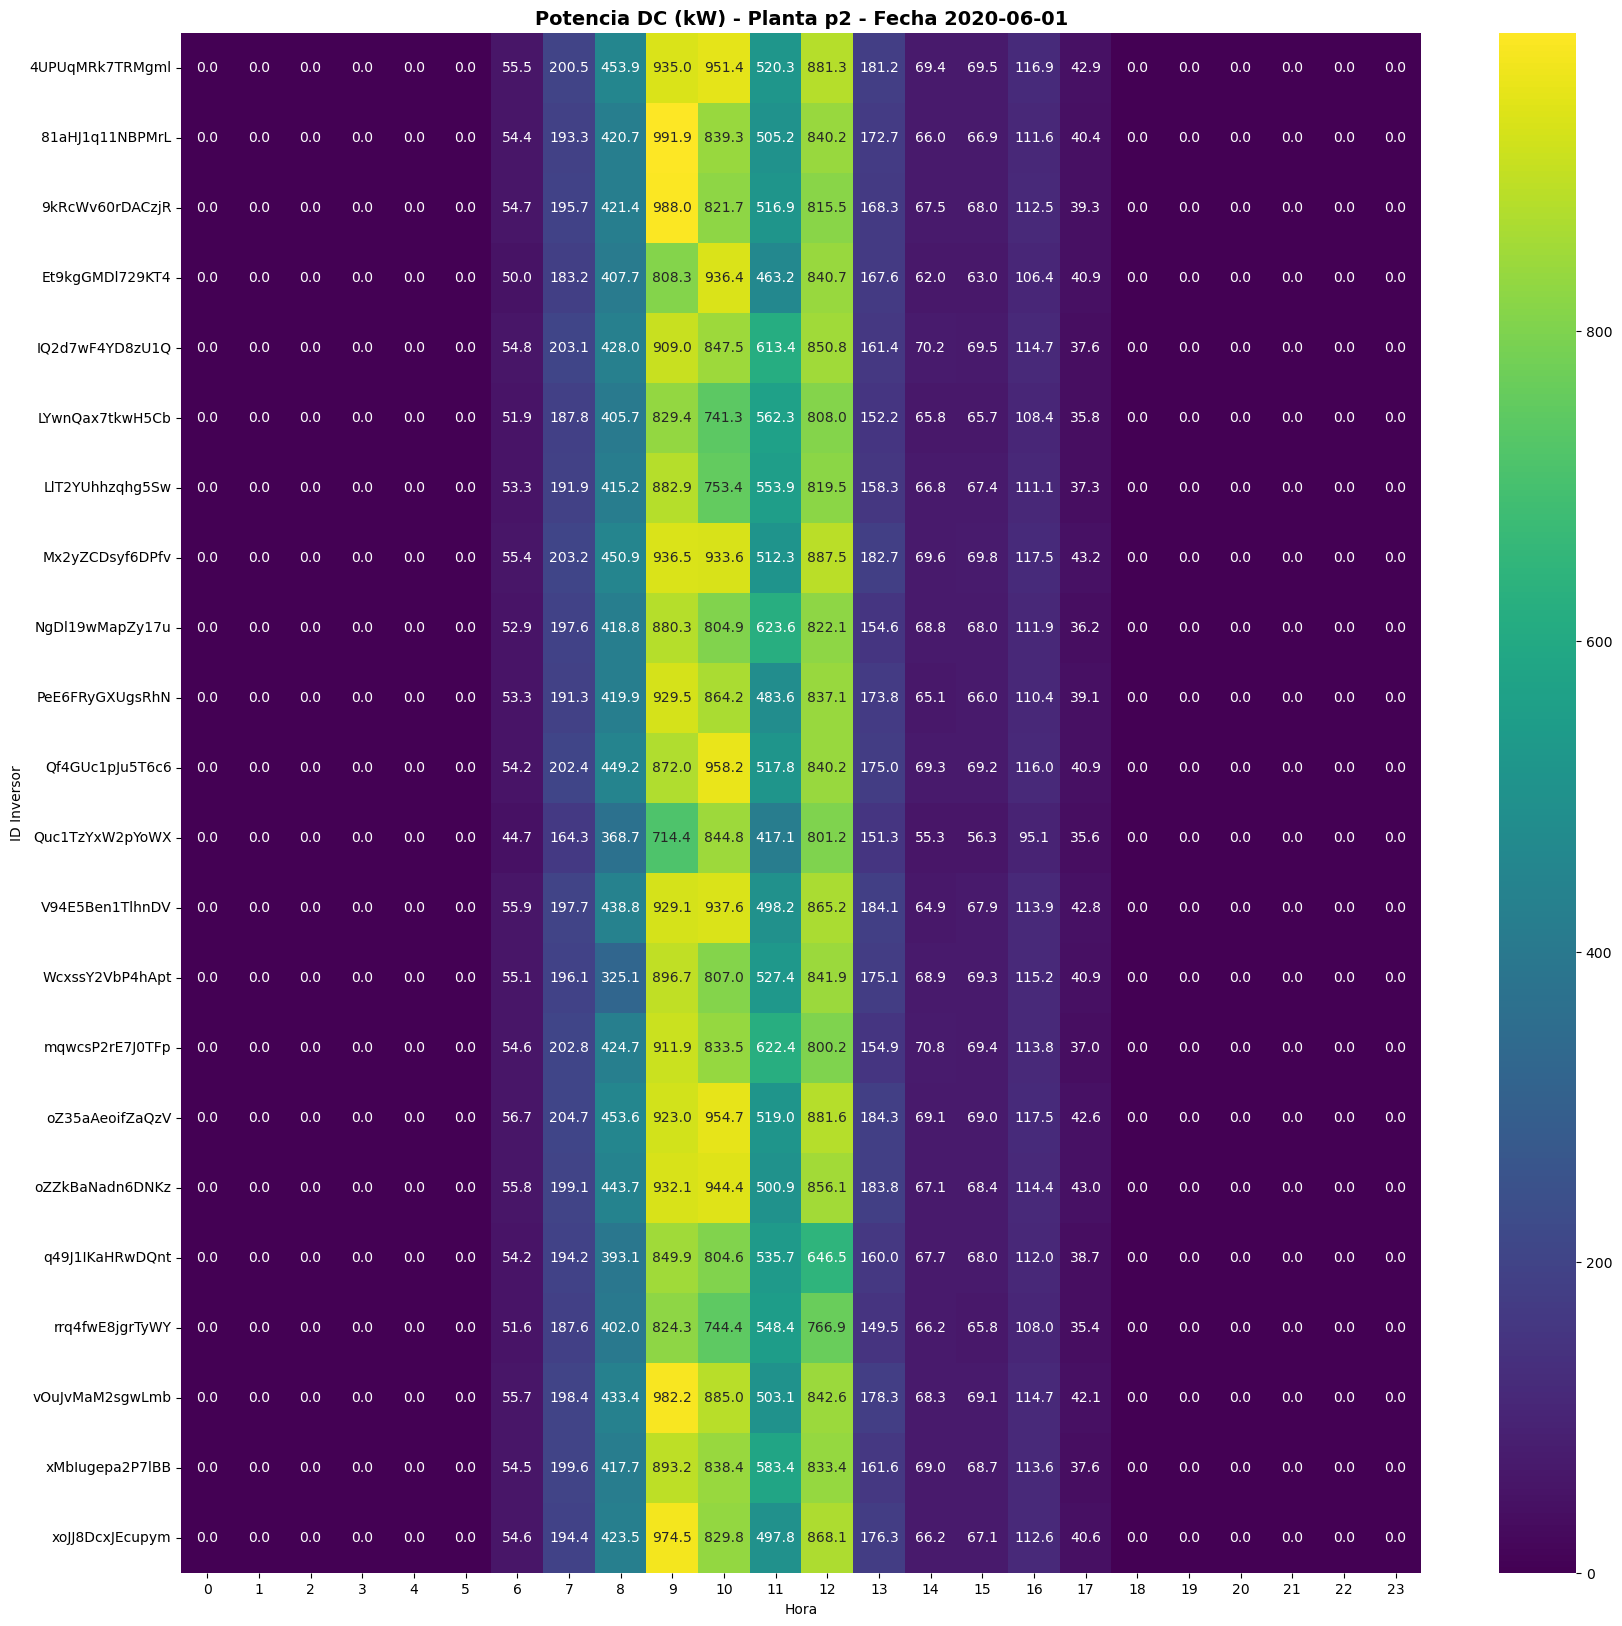

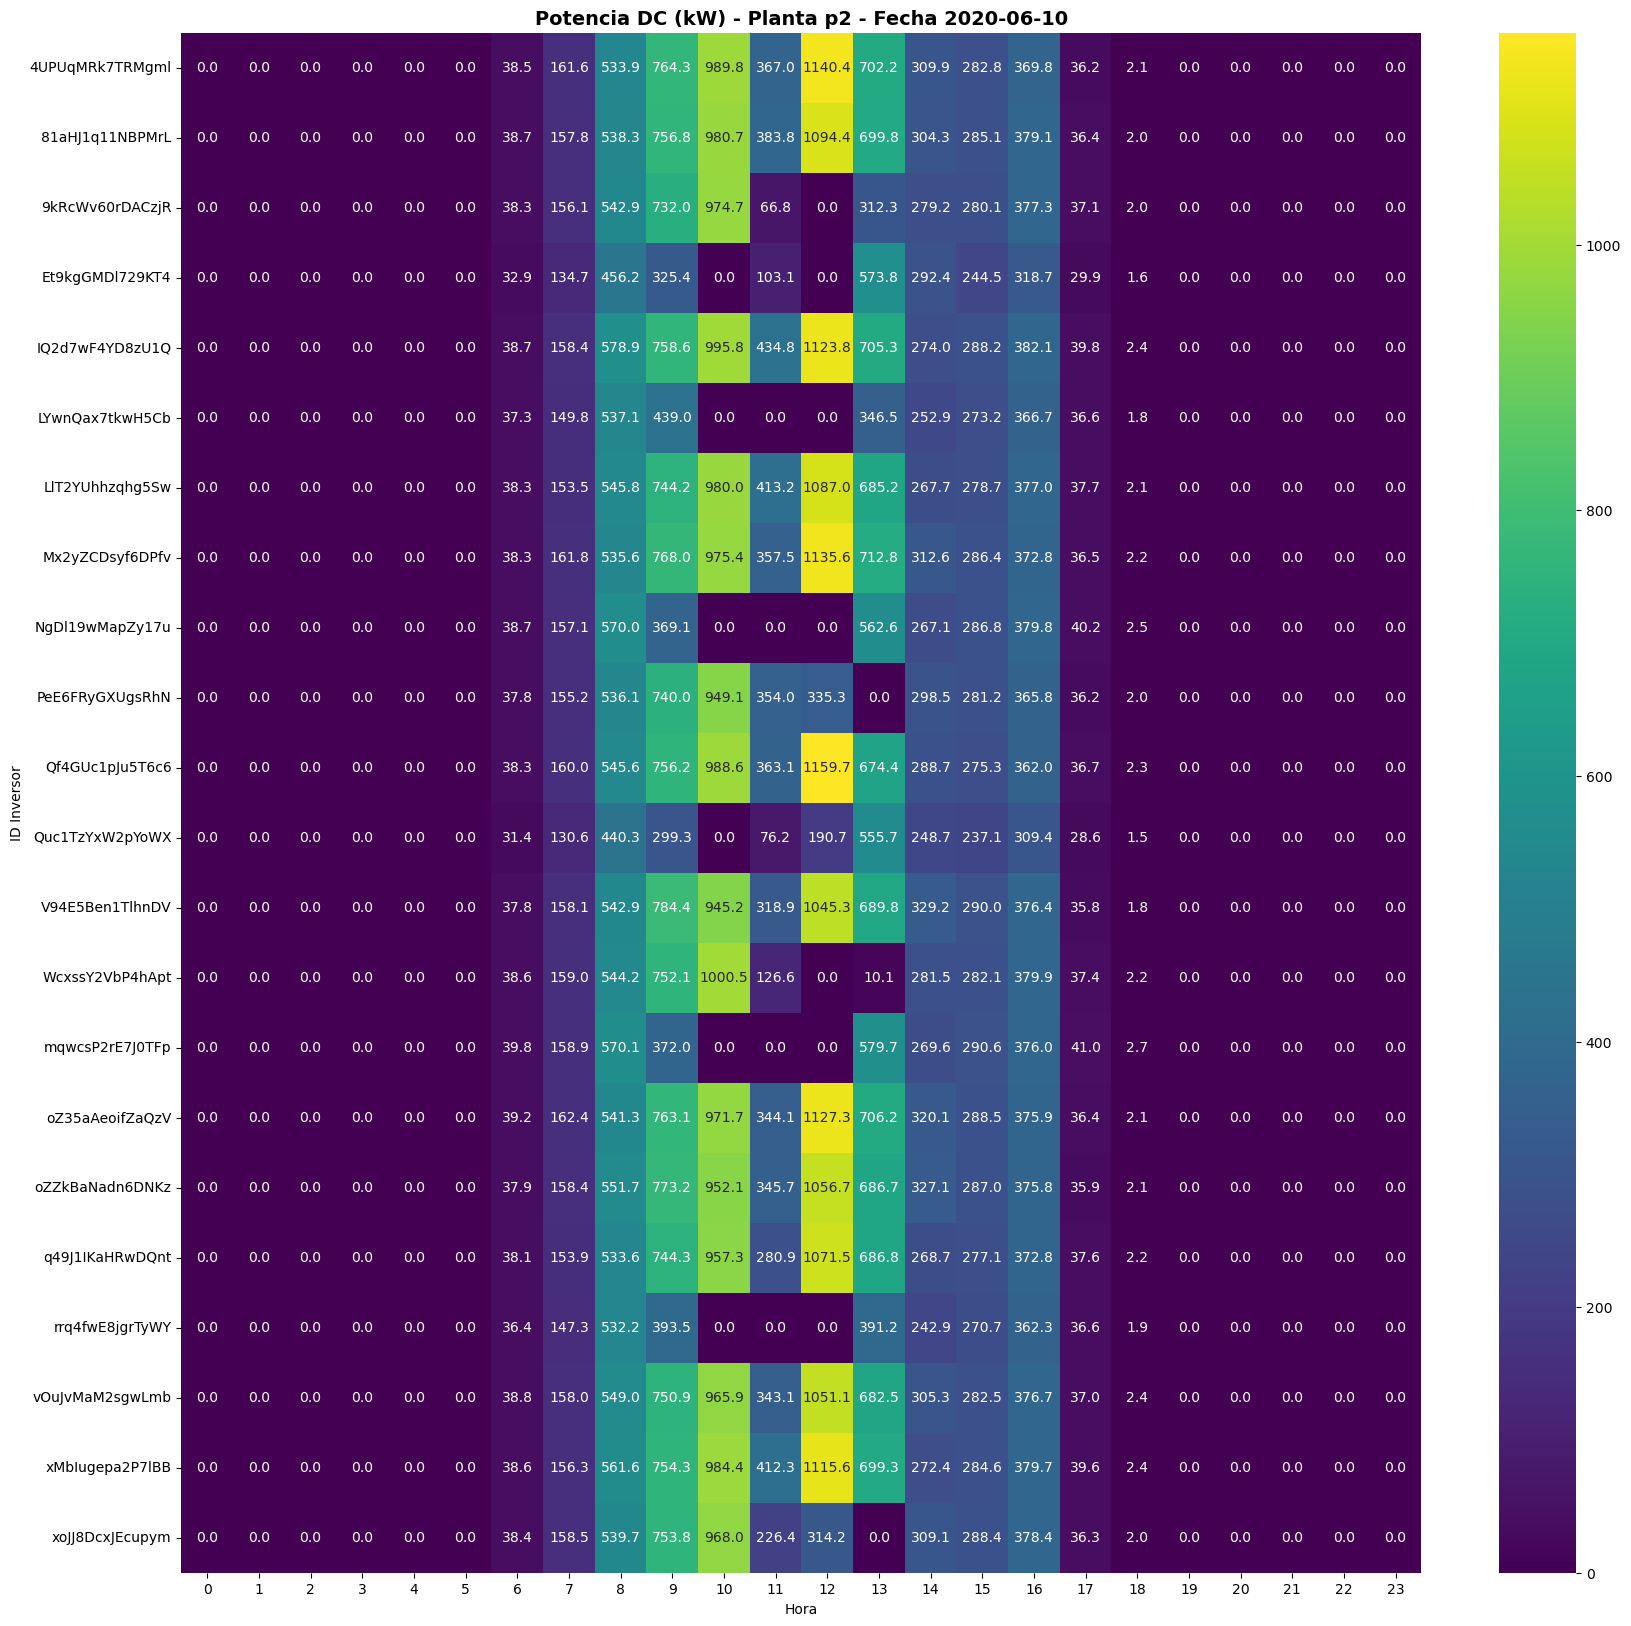

In [74]:
# sobre df_problemas quiero un grafico para cada planta y dia, y que sea un heatmap con cada inverter en las filas y cada hora en las columnas, y el valor la media de potencia_dc_kw
for planta in df_problemas['id_planta'].unique():
    df_planta = df_problemas[df_problemas['id_planta'] == planta]
    for fecha in df_planta['fecha'].unique():
        df_dia = df_planta[df_planta['fecha'] == fecha]
        pivot = df_dia.pivot_table(index='id_inversor', columns='hora', values='potencia_dc_kw', aggfunc='mean')
        
        plt.figure(figsize=(20, 20))
        sns.heatmap(pivot, cmap='viridis', annot=True, fmt='.1f')
        plt.title(f'Potencia DC (kW) - Planta {planta} - Fecha {fecha}', fontsize=14, fontweight='bold')
        plt.xlabel('Hora')
        plt.ylabel('ID Inversor')
        plt.show()

In [75]:
# Detecta combinaciones problemáticas de planta, día, hora e inversor

resultados = []

for planta in df_problemas['id_planta'].unique():
    df_planta = df_problemas[df_problemas['id_planta'] == planta]
    for fecha in df_planta['fecha'].unique():
        df_dia = df_planta[df_planta['fecha'] == fecha]
        for inversor in df_dia['id_inversor'].unique():
            df_inv = df_dia[df_dia['id_inversor'] == inversor].sort_values('hora')
            potencias = df_inv['potencia_dc_kw'].values
            horas = df_inv['hora'].values
            for i, (h, p) in enumerate(zip(horas, potencias)):
                # Caso 1: potencia cero
                if p == 0:
                    resultados.append([planta, fecha, inversor, h, p, 'potencia_cero'])
                # Caso 2: potencia muy baja respecto a horas colindantes
                else:
                    vecinos = []
                    if i > 0:
                        vecinos.append(potencias[i-1])
                    if i < len(potencias)-1:
                        vecinos.append(potencias[i+1])
                    if vecinos:
                        media_vecinos = np.mean(vecinos)
                        if media_vecinos > 0 and p < 0.7 * media_vecinos:
                            resultados.append([planta, fecha, inversor, h, p, 'potencia_baja'])

df_fallos = pd.DataFrame(resultados, columns=['id_planta', 'fecha', 'id_inversor', 'hora', 'potencia_dc_kw', 'tipo_fallo'])
df_fallos

,id_planta,fecha,id_inversor,hora,potencia_dc_kw,tipo_fallo
0,p1,2020-05-20,1BY6WEcLGh8j5v7,0,0.0,potencia_cero
1,p1,2020-05-20,1BY6WEcLGh8j5v7,0,0.0,potencia_cero
2,p1,2020-05-20,1BY6WEcLGh8j5v7,0,0.0,potencia_cero
3,p1,2020-05-20,1BY6WEcLGh8j5v7,0,0.0,potencia_cero
4,p1,2020-05-20,1BY6WEcLGh8j5v7,1,0.0,potencia_cero
...,...,...,...,...,...,...
8136,p2,2020-06-10,xoJJ8DcxJEcupym,22,0.0,potencia_cero
8137,p2,2020-06-10,xoJJ8DcxJEcupym,23,0.0,potencia_cero
8138,p2,2020-06-10,xoJJ8DcxJEcupym,23,0.0,potencia_cero
8139,p2,2020-06-10,xoJJ8DcxJEcupym,23,0.0,potencia_cero


In [77]:
# ============================================
# INFORME EJECUTIVO: ANÁLISIS DE FALLOS
# ============================================

print("=" * 80)
print("INFORME EJECUTIVO: ANÁLISIS DETALLADO DE FALLOS EN INVERSORES")
print("=" * 80)
print()

# 1. RESUMEN GENERAL POR TIPO DE FALLO
print("1. DISTRIBUCIÓN GENERAL DE FALLOS")
print("-" * 80)
tipo_fallo_summary = df_fallos['tipo_fallo'].value_counts()
total_fallos = len(df_fallos)
print(f"Total de registros con fallo: {total_fallos:,}")
print()
for tipo, count in tipo_fallo_summary.items():
    pct = (count / total_fallos) * 100
    print(f"  • {tipo.upper()}: {count:,} registros ({pct:.1f}%)")
print()
print()

# 2. ANÁLISIS POR PLANTA
print("2. FALLOS POR PLANTA")
print("-" * 80)
fallos_planta = df_fallos.groupby(['id_planta', 'tipo_fallo']).size().unstack(fill_value=0)
print(fallos_planta)
print()
print("Conclusión: ", end="")
if fallos_planta.sum(axis=1)['p2'] > fallos_planta.sum(axis=1)['p1']:
    ratio = fallos_planta.sum(axis=1)['p2'] / fallos_planta.sum(axis=1)['p1']
    print(f"La Planta P2 presenta {ratio:.1f}x más incidencias que P1.")
else:
    print("Ambas plantas presentan niveles similares de incidencias.")
print()
print()

# 3. TOP 10 INVERSORES MÁS PROBLEMÁTICOS
print("3. TOP 10 INVERSORES CON MÁS INCIDENCIAS")
print("-" * 80)
top_inversores = df_fallos.groupby(['id_planta', 'id_inversor']).size().sort_values(ascending=False).head(10)
print(top_inversores.to_frame(name='n_incidencias'))
print()
print("⚠️  ACCIÓN REQUERIDA: Estos inversores deben ser revisados prioritariamente")
print("   para mantenimiento preventivo o correctivo.")
print()
print()

# 4. DÍAS CRÍTICOS
print("4. DÍAS CON MAYOR CONCENTRACIÓN DE FALLOS")
print("-" * 80)
top_dias = df_fallos.groupby(['id_planta', 'fecha']).size().sort_values(ascending=False).head(10)
print(top_dias.to_frame(name='n_incidencias'))
print()
print()

# 5. HORAS CRÍTICAS DEL DÍA
print("5. DISTRIBUCIÓN HORARIA DE FALLOS")
print("-" * 80)
fallos_hora = df_fallos.groupby('hora').size().sort_values(ascending=False)
print(fallos_hora.head(10).to_frame(name='n_incidencias'))
print()
print("💡 Insight: ", end="")
horas_produccion = fallos_hora[(fallos_hora.index >= 6) & (fallos_hora.index <= 18)]
if len(horas_produccion) > 0:
    print(f"El {(horas_produccion.sum() / fallos_hora.sum() * 100):.1f}% de los fallos ocurren")
    print("   durante las horas de producción (6h-18h), maximizando el impacto económico.")
else:
    print("La mayoría de fallos ocurren fuera de las horas de producción.")
print()
print()

# 6. CASOS MÁS CRÍTICOS: Combinaciones específicas
print("6. TOP 15 COMBINACIONES CRÍTICAS (Planta-Fecha-Inversor-Hora)")
print("-" * 80)
casos_criticos = df_fallos.groupby(['id_planta', 'fecha', 'id_inversor', 'hora', 'tipo_fallo']).agg({
    'potencia_dc_kw': 'mean'
}).reset_index()
casos_criticos['n_registros'] = df_fallos.groupby(['id_planta', 'fecha', 'id_inversor', 'hora', 'tipo_fallo']).size().values
casos_criticos_top = casos_criticos.sort_values('n_registros', ascending=False).head(15)
print(casos_criticos_top.to_string(index=False))
print()
print()

# 7. ANÁLISIS DE CAUSAS POTENCIALES
print("7. DIAGNÓSTICO DE CAUSAS POTENCIALES")
print("-" * 80)
print()
print("📋 POTENCIA CERO:")
if 'potencia_cero' in tipo_fallo_summary.index:
    print("   • Desconexión total del inversor")
    print("   • Activación de protecciones (sobrecorriente, sobretensión, temperatura)")
    print("   • Pérdida de comunicación con el controlador")
    print("   • Mantenimiento no programado o parada de emergencia")
    print("   • Fallo en el string DC o problema en los módulos fotovoltaicos")
    print()
    
if 'potencia_baja' in tipo_fallo_summary.index:
    print("📋 POTENCIA BAJA ANÓMALA:")
    print("   • Degradación progresiva del inversor")
    print("   • Sombreado parcial o suciedad en módulos (aunque poco probable)")
    print("   • Fallo intermitente en componentes internos")
    print("   • Curtailment o limitación externa de potencia")
    print("   • Desbalance en strings o pérdida de MPPTs")
    print()
print()

# 8. RECOMENDACIONES ESTRATÉGICAS
print("8. RECOMENDACIONES ESTRATÉGICAS")
print("-" * 80)
print()
print("🔧 ACCIONES INMEDIATAS:")
print("   1. Inspección técnica de los inversores con más de 100 incidencias")
print("   2. Revisión de logs de protecciones y alarmas en días críticos identificados")
print("   3. Verificación de conexiones DC y estado de strings fotovoltaicos")
print()
print("📊 ACCIONES DE MEDIANO PLAZO:")
print("   4. Implementar sistema de monitorización predictiva en inversores críticos")
print("   5. Evaluar costes de reemplazo vs. reparación en equipos recurrentes")
print("   6. Optimizar calendario de mantenimiento preventivo basado en patrones horarios")
print()
print("💰 IMPACTO ECONÓMICO:")
print("   7. Cuantificar energía no generada durante episodios de fallo")
print("   8. Calcular pérdidas económicas y comparar con coste de soluciones")
print("   9. Priorizar inversiones en equipos con mayor impacto en disponibilidad")
print()
print()
print("=" * 80)
print("FIN DEL INFORME")
print("=" * 80)

INFORME EJECUTIVO: ANÁLISIS DETALLADO DE FALLOS EN INVERSORES

1. DISTRIBUCIÓN GENERAL DE FALLOS
--------------------------------------------------------------------------------
Total de registros con fallo: 8,141

  • POTENCIA_CERO: 6,938 registros (85.2%)
  • POTENCIA_BAJA: 1,203 registros (14.8%)


2. FALLOS POR PLANTA
--------------------------------------------------------------------------------
tipo_fallo  potencia_baja  potencia_cero
id_planta                               
p1                    517           2876
p2                    686           4062

Conclusión: La Planta P2 presenta 1.4x más incidencias que P1.


3. TOP 10 INVERSORES CON MÁS INCIDENCIAS
--------------------------------------------------------------------------------
                           n_incidencias
id_planta id_inversor                   
p2        81aHJ1q11NBPMrL            258
          LYwnQax7tkwH5Cb            258
          xoJJ8DcxJEcupym            249
          rrq4fwE8jgrTyWY            2